# Notebook 13 — IMU Sensor Fusion & Visual-Inertial Odometry

**Vision & 3D Mapping Workshop** | Block 5: Sensor Fusion

---

## Why This Matters

Cameras see rich geometry but are slow, brittle in the dark, and suffer from scale ambiguity.
Inertial Measurement Units (IMUs) provide high-rate, metric-scale motion information but
drift catastrophically on their own.  **Visual-Inertial Odometry (VIO)** fuses the two into
a state estimator that is fast, accurate, and robust — the gold standard for real-time
navigation on phones, drones, and AR headsets.

Every production VIO system — Apple ARKit, Google ARCore, DJI flight controllers, Meta
Quest tracking — uses a variant of what we derive here. This notebook covers the theory
from first principles and implements a working EKF in NumPy.

### What You'll Learn

- How IMU accelerometers and gyroscopes model the physical world (measurement equations, bias, noise)
- Why IMU-only dead reckoning drifts catastrophically as $O(t^3)$ — and how to prove it
- The full error-state Extended Kalman Filter (15-D state) for fusing IMU with visual odometry
- The complementary filter: a simple frequency-domain alternative for attitude estimation
- IMU preintegration on $\text{SO}(3)$: how to avoid costly re-integration during optimisation
- Factor graphs vs EKF: why modern VIO systems (OKVIS, VINS-Mono) prefer graph optimisation
- Continuous-time trajectory representations (B-splines, Gaussian processes) for asynchronous multi-sensor fusion
- Camera-IMU calibration: spatial extrinsics, temporal offsets, and observability requirements

### Roadmap

1. **IMU Basics** — accelerometer and gyroscope measurement models
2. **IMU Dead Reckoning** — why double-integrating accelerations drifts as $t^3$
3. **Extended Kalman Filter** — full error-state EKF derivation (15-D state)
4. **Implementation** — fusing IMU + visual odometry on a synthetic trajectory
4b. **Complementary Filter** — a simpler frequency-domain alternative for attitude estimation
5. **IMU Preintegration** — deriving preintegrated measurements on $\text{SO}(3)$
6. **Factor Graphs vs EKF** — why modern VIO uses graph optimization
7. **Continuous-Time Trajectories** — B-splines and Gaussian process priors
8. **Camera-IMU Calibration** — spatial extrinsics, temporal offsets, and observability
9. **Exercises** — hands-on IMU simulation, EKF implementation, and trajectory fusion

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Ellipse
from scipy.spatial.transform import Rotation

from src.ekf import VIO_EKF

np.set_printoptions(precision=6, suppress=True)
np.random.seed(42)

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

---

## 1. IMU Basics

An Inertial Measurement Unit packages two complementary sensors:

| Sensor | Measures | Output |
|:---|:---|:---|
| **Accelerometer** | Specific force (gravity + linear acceleration) | $\mathbf{a}_m \in \mathbb{R}^3$ |
| **Gyroscope** | Angular velocity | $\boldsymbol{\omega}_m \in \mathbb{R}^3$ |

### 1.1 Accelerometer Model

The accelerometer measures the *specific force* — the difference between the true
acceleration and gravitational acceleration — expressed in the **body frame**:

$$
\boxed{\mathbf{a}_m = R^\top(\mathbf{a}_{\text{world}} - \mathbf{g}) + \mathbf{b}_a + \mathbf{n}_a}
$$

where:
- $R \in \text{SO}(3)$ is the rotation from body to world frame,
- $\mathbf{a}_{\text{world}} \in \mathbb{R}^3$ is the true acceleration in the world frame,
- $\mathbf{g} = [0, 0, -g]^\top$ is gravitational acceleration ($g \approx 9.81\;\text{m/s}^2$),
- $\mathbf{b}_a \in \mathbb{R}^3$ is the slowly time-varying **accelerometer bias**,
- $\mathbf{n}_a \sim \mathcal{N}(\mathbf{0}, \sigma_a^2 I)$ is additive white Gaussian noise.

**Key insight:** When the sensor is stationary ($\mathbf{a}_{\text{world}} = \mathbf{0}$),
the accelerometer reads $\mathbf{a}_m = -R^\top \mathbf{g} + \mathbf{b}_a + \mathbf{n}_a$.
This tells us the direction of gravity in the body frame — which is how phones know which
way is "up".

### 1.2 Gyroscope Model

The gyroscope measures angular velocity in the **body frame**:

$$
\boxed{\boldsymbol{\omega}_m = \boldsymbol{\omega} + \mathbf{b}_g + \mathbf{n}_g}
$$

where:
- $\boldsymbol{\omega} \in \mathbb{R}^3$ is the true angular velocity,
- $\mathbf{b}_g \in \mathbb{R}^3$ is the gyroscope bias,
- $\mathbf{n}_g \sim \mathcal{N}(\mathbf{0}, \sigma_g^2 I)$ is additive white noise.

### 1.3 Bias Model

IMU biases drift slowly over time.  The standard model is a **random walk**:

$$
\frac{d\mathbf{b}_a}{dt} = \mathbf{n}_{b_a}, \qquad
\frac{d\mathbf{b}_g}{dt} = \mathbf{n}_{b_g}
$$

where $\mathbf{n}_{b_a} \sim \mathcal{N}(\mathbf{0}, \sigma_{b_a}^2 I)$ and
$\mathbf{n}_{b_g} \sim \mathcal{N}(\mathbf{0}, \sigma_{b_g}^2 I)$.

In discrete time with step $\Delta t$:

$$
\mathbf{b}_{a,k+1} = \mathbf{b}_{a,k} + \mathbf{n}_{b_a}\sqrt{\Delta t}, \qquad
\mathbf{b}_{g,k+1} = \mathbf{b}_{g,k} + \mathbf{n}_{b_g}\sqrt{\Delta t}
$$

### 1.4 Typical Sensor Specifications

| Parameter | Symbol | Consumer-grade | Tactical-grade |
|:---|:---|:---|:---|
| Accel noise density | $\sigma_a$ | $\approx 0.1\;\text{m/s}^2/\sqrt{\text{Hz}}$ | $\approx 0.01\;\text{m/s}^2/\sqrt{\text{Hz}}$ |
| Gyro noise density | $\sigma_g$ | $\approx 0.01\;\text{rad/s}/\sqrt{\text{Hz}}$ | $\approx 0.001\;\text{rad/s}/\sqrt{\text{Hz}}$ |
| Accel bias instability$^\dagger$ | $\sigma_{b_a}$ | $\approx 0.001\;\text{m/s}^2/\sqrt{\text{s}}$ | $\approx 10^{-4}\;\text{m/s}^2/\sqrt{\text{s}}$ |
| Gyro bias instability$^\dagger$ | $\sigma_{b_g}$ | $\approx 10^{-4}\;\text{rad/s}/\sqrt{\text{s}}$ | $\approx 10^{-6}\;\text{rad/s}/\sqrt{\text{s}}$ |
| Sample rate | $f_s$ | $100$–$400\;\text{Hz}$ | $1000+\;\text{Hz}$ |

$^\dagger$ Bias instability values are amplitude spectral densities of the
random walk driving noise $\dot{b} = n_b$.  Since $\dot{b}$ has units m/s³
(accel) or rad/s² (gyro), the spectral density $\sigma_b$ has units
m/s³/$\sqrt{\text{Hz}}$ = m/s²·s$^{-1/2}$ (accel) and
rad/s²/$\sqrt{\text{Hz}}$ = rad/s·s$^{-1/2}$ (gyro).
The discrete-time bias variance increment per step is
$\sigma_b^2 \Delta t$.

---

## 2. IMU Dead Reckoning and Drift Analysis

### 2.1 From Acceleration to Position

Given bias-corrected, world-frame accelerations, position is recovered by
**double integration**:

$$
\mathbf{v}(t) = \mathbf{v}_0 + \int_0^t \mathbf{a}(\tau)\,d\tau, \qquad
\mathbf{p}(t) = \mathbf{p}_0 + \int_0^t \mathbf{v}(\tau)\,d\tau
$$

### 2.2 Why Drift Grows as $t^3$

Let accelerometer noise be white with power spectral density $\sigma_a^2$.

**First integration** (velocity): integrating white noise gives a random walk.
The velocity error variance grows linearly:

$$
\text{Var}[\delta v(t)] = \sigma_a^2 \, t
$$

**Second integration** (position): integrating the random-walk velocity error
yields position error variance that grows as $t^3$:

$$
\boxed{\text{Var}[\delta p(t)] = \frac{1}{3}\sigma_a^2 \, t^3}
$$

**Derivation:**

$$
\delta p(t) = \int_0^t \delta v(\tau)\,d\tau = \int_0^t \left(\int_0^\tau n_a(s)\,ds\right) d\tau
$$

Swapping the order of integration (Fubini's theorem):

$$
\delta p(t) = \int_0^t n_a(s) \left(\int_s^t d\tau\right) ds = \int_0^t (t - s)\,n_a(s)\,ds
$$

The variance is:

$$
\text{Var}[\delta p(t)] = \int_0^t (t-s)^2 \sigma_a^2\,ds = \sigma_a^2 \frac{t^3}{3}
$$

Additionally, **gyroscope bias** causes orientation error that grows linearly,
which in turn causes a gravity projection error that is integrated twice — yielding
$O(t^3)$ position error from bias alone, and up to $O(t^5)$ when bias drift is included.

This cubic (or worse) drift is why standalone IMU navigation is hopeless for more
than a few seconds with consumer-grade sensors.

### 2.3 Synthetic Ground-Truth Trajectory

We generate a figure-8 trajectory in 3D that all subsequent sections will use.

In [2]:
# ── Ground-truth figure-8 trajectory ──────────────────────────────────

dt_imu = 0.005          # 200 Hz IMU
dt_vo = 0.1             # 10 Hz visual odometry
T_total = 20.0          # 20 seconds
t_imu = np.arange(0, T_total, dt_imu)
N_imu = len(t_imu)

omega_traj = 2.0 * np.pi / T_total  # one full period

# Figure-8 in XY, gentle sinusoidal in Z
gt_pos = np.column_stack([
    4.0 * np.sin(omega_traj * t_imu),
    4.0 * np.sin(2.0 * omega_traj * t_imu),
    0.5 * np.sin(omega_traj * t_imu),
])

# Ground-truth velocity (analytical derivative)
gt_vel = np.column_stack([
    4.0 * omega_traj * np.cos(omega_traj * t_imu),
    4.0 * 2.0 * omega_traj * np.cos(2.0 * omega_traj * t_imu),
    0.5 * omega_traj * np.cos(omega_traj * t_imu),
])

# Ground-truth acceleration (analytical second derivative)
gt_acc = np.column_stack([
    -4.0 * omega_traj**2 * np.sin(omega_traj * t_imu),
    -4.0 * (2.0 * omega_traj)**2 * np.sin(2.0 * omega_traj * t_imu),
    -0.5 * omega_traj**2 * np.sin(omega_traj * t_imu),
])

# Ground-truth orientation: body x-axis aligned with velocity direction
gt_quats = np.zeros((N_imu, 4))
for i in range(N_imu):
    v = gt_vel[i]
    speed = np.linalg.norm(v)
    if speed > 1e-6:
        forward = v / speed
    else:
        forward = np.array([1.0, 0.0, 0.0])
    world_up = np.array([0.0, 0.0, 1.0])
    right = np.cross(forward, world_up)
    right_norm = np.linalg.norm(right)
    if right_norm > 1e-6:
        right /= right_norm
    else:
        right = np.array([0.0, 1.0, 0.0])
    up = np.cross(right, forward)
    up /= np.linalg.norm(up)
    R_gt = np.column_stack([forward, right, up])
    if np.linalg.det(R_gt) < 0:
        right = -right
        R_gt = np.column_stack([forward, right, up])
    r = Rotation.from_matrix(R_gt)
    q = r.as_quat()  # [x,y,z,w] in scipy
    gt_quats[i] = np.array([q[3], q[0], q[1], q[2]])  # convert to [w,x,y,z]

print(f"Trajectory: {T_total}s, {N_imu} IMU samples at {1/dt_imu:.0f} Hz")
print(f"Position range: X [{gt_pos[:,0].min():.1f}, {gt_pos[:,0].max():.1f}], "
      f"Y [{gt_pos[:,1].min():.1f}, {gt_pos[:,1].max():.1f}], "
      f"Z [{gt_pos[:,2].min():.1f}, {gt_pos[:,2].max():.1f}]")

Trajectory: 20.0s, 4000 IMU samples at 200 Hz
Position range: X [-4.0, 4.0], Y [-4.0, 4.0], Z [-0.5, 0.5]


In [3]:
# ── Simulate IMU measurements ────────────────────────────────────────

gravity = np.array([0.0, 0.0, -9.81])

# Noise parameters (consumer-grade IMU)
sigma_a = 0.1        # m/s²/√Hz
sigma_g = 0.01       # rad/s/√Hz
sigma_ba = 0.001     # accel bias random walk
sigma_bg = 0.0001    # gyro bias random walk

# True biases (slowly drifting)
true_accel_bias = np.zeros((N_imu, 3))
true_gyro_bias = np.zeros((N_imu, 3))
true_accel_bias[0] = np.array([0.02, -0.01, 0.03])
true_gyro_bias[0] = np.array([0.001, -0.0005, 0.0008])

for i in range(1, N_imu):
    true_accel_bias[i] = true_accel_bias[i-1] + sigma_ba * np.sqrt(dt_imu) * np.random.randn(3)
    true_gyro_bias[i] = true_gyro_bias[i-1] + sigma_bg * np.sqrt(dt_imu) * np.random.randn(3)

# Generate noisy IMU readings
imu_accel = np.zeros((N_imu, 3))
imu_gyro = np.zeros((N_imu, 3))

# Ground-truth angular velocity via finite differences of rotation
gt_omega = np.zeros((N_imu, 3))
for i in range(N_imu - 1):
    R_i = Rotation.from_quat([gt_quats[i, 1], gt_quats[i, 2], gt_quats[i, 3], gt_quats[i, 0]])
    R_next = Rotation.from_quat([gt_quats[i+1, 1], gt_quats[i+1, 2], gt_quats[i+1, 3], gt_quats[i+1, 0]])
    dR = R_i.inv() * R_next
    gt_omega[i] = dR.as_rotvec() / dt_imu
gt_omega[-1] = gt_omega[-2]

for i in range(N_imu):
    R_wb = Rotation.from_quat([gt_quats[i, 1], gt_quats[i, 2], gt_quats[i, 3], gt_quats[i, 0]])
    R_bw = R_wb.inv()
    # Accelerometer: a_m = R^T(a_world - g) + bias + noise
    imu_accel[i] = (R_bw.as_matrix() @ (gt_acc[i] - gravity)
                    + true_accel_bias[i]
                    + sigma_a * np.sqrt(1.0/dt_imu) * np.random.randn(3))
    # Gyroscope: ω_m = ω + bias + noise
    imu_gyro[i] = (gt_omega[i]
                   + true_gyro_bias[i]
                   + sigma_g * np.sqrt(1.0/dt_imu) * np.random.randn(3))

print(f"IMU data generated: accel shape {imu_accel.shape}, gyro shape {imu_gyro.shape}")
print(f"Accel bias drift range: {np.ptp(true_accel_bias, axis=0)}")

IMU data generated: accel shape (4000, 3), gyro shape (4000, 3)
Accel bias drift range: [0.004564 0.009055 0.005122]


### 2.4 Dead Reckoning: Demonstrating Catastrophic Drift

In [4]:
# ── IMU-only dead reckoning (double integration) ─────────────────────

dr_pos = np.zeros((N_imu, 3))
dr_vel = np.zeros((N_imu, 3))
dr_quat = np.array([1.0, 0.0, 0.0, 0.0])  # start at identity

dr_pos[0] = gt_pos[0].copy()
dr_vel[0] = gt_vel[0].copy()
dr_quat = gt_quats[0].copy()

for i in range(1, N_imu):
    # Integrate gyroscope → orientation
    w = imu_gyro[i-1]
    angle = np.linalg.norm(w) * dt_imu
    if angle > 1e-12:
        axis = w / np.linalg.norm(w)
        dq = np.array([np.cos(angle/2), *(np.sin(angle/2) * axis)])
    else:
        dq = np.array([1.0, 0.0, 0.0, 0.0])

    # Quaternion multiplication (Hamilton, scalar-first)
    w0, x0, y0, z0 = dr_quat
    w1, x1, y1, z1 = dq
    dr_quat = np.array([
        w0*w1 - x0*x1 - y0*y1 - z0*z1,
        w0*x1 + x0*w1 + y0*z1 - z0*y1,
        w0*y1 - x0*z1 + y0*w1 + z0*x1,
        w0*z1 + x0*y1 - y0*x1 + z0*w1,
    ])
    dr_quat /= np.linalg.norm(dr_quat)

    R_dr = Rotation.from_quat([dr_quat[1], dr_quat[2], dr_quat[3], dr_quat[0]]).as_matrix()

    # Rotate accelerometer reading to world frame and remove gravity
    a_world = R_dr @ imu_accel[i-1] + gravity

    # Double integration
    dr_vel[i] = dr_vel[i-1] + a_world * dt_imu
    dr_pos[i] = dr_pos[i-1] + dr_vel[i-1] * dt_imu + 0.5 * a_world * dt_imu**2

print(f"Dead-reckoning final position error: {np.linalg.norm(dr_pos[-1] - gt_pos[-1]):.1f} m")

Dead-reckoning final position error: 44.8 m


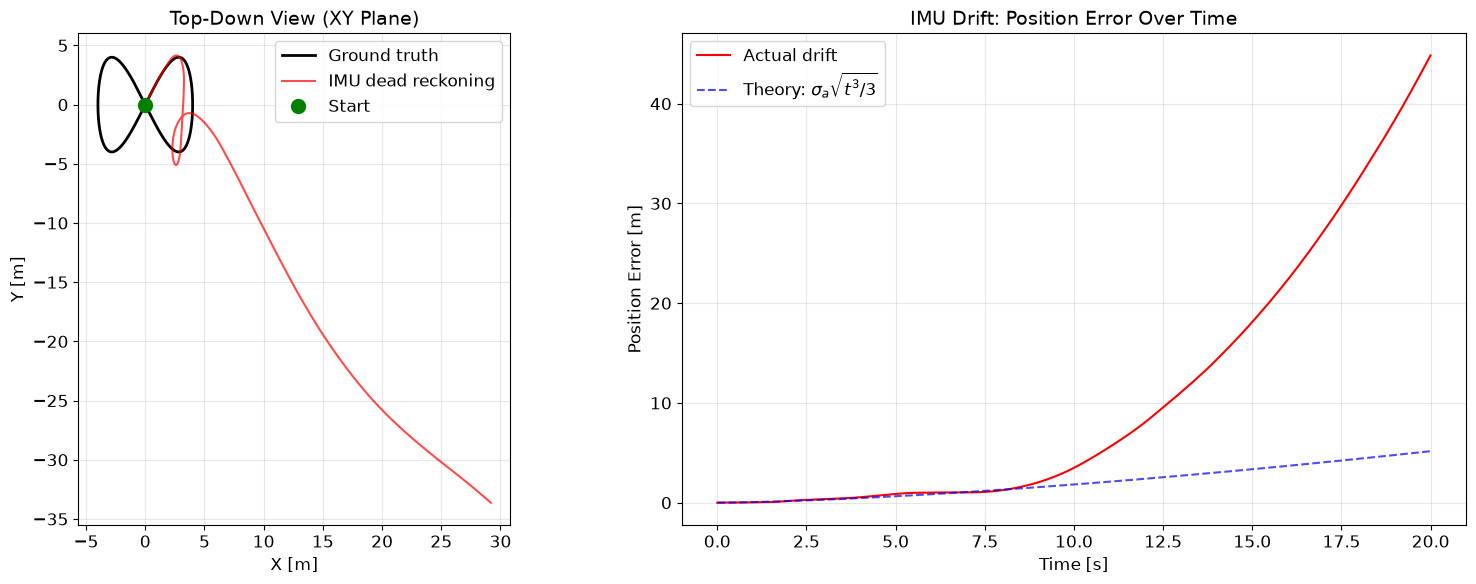


Drift at t=5s:  actual=0.88 m, theory=0.65 m
Drift at t=20s: actual=44.83 m, theory=5.16 m


In [5]:
# ── Plot: IMU dead reckoning vs ground truth ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2D top-down view
axes[0].plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', lw=2, label='Ground truth')
axes[0].plot(dr_pos[:, 0], dr_pos[:, 1], 'r-', lw=1.5, alpha=0.7, label='IMU dead reckoning')
axes[0].plot(gt_pos[0, 0], gt_pos[0, 1], 'go', ms=10, label='Start')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Y [m]')
axes[0].set_title('Top-Down View (XY Plane)')
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Position error over time
pos_error = np.linalg.norm(dr_pos - gt_pos, axis=1)
t_theory = t_imu[1:]
drift_theory = sigma_a * np.sqrt(t_theory**3 / 3)

axes[1].plot(t_imu, pos_error, 'r-', lw=1.5, label='Actual drift')
axes[1].plot(t_theory, drift_theory, 'b--', lw=1.5, alpha=0.7, label=r'Theory: $\sigma_a\sqrt{t^3/3}$')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Position Error [m]')
axes[1].set_title('IMU Drift: Position Error Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDrift at t=5s:  actual={pos_error[int(5/dt_imu)]:.2f} m, "
      f"theory={sigma_a * np.sqrt(5**3/3):.2f} m")
print(f"Drift at t=20s: actual={pos_error[-1]:.2f} m, "
      f"theory={sigma_a * np.sqrt(20**3/3):.2f} m")

---

## 3. Extended Kalman Filter — Full Derivation

The EKF fuses high-rate IMU data with low-rate visual pose measurements.
We use the **error-state (multiplicative) formulation**, which keeps the
error state in a vector space where Kalman filter linear algebra is valid.

### 3.1 State Definition

The **nominal state** is:

$$
\mathbf{x} = \begin{bmatrix} \mathbf{p} \\ \mathbf{v} \\ \mathbf{q} \\ \mathbf{b}_a \\ \mathbf{b}_g \end{bmatrix}
\in \mathbb{R}^3 \times \mathbb{R}^3 \times S^3 \times \mathbb{R}^3 \times \mathbb{R}^3
$$

The **error state** is 15-dimensional (using rotation vector $\delta\boldsymbol{\theta} \in \mathbb{R}^3$
instead of the 4-D quaternion):

$$
\delta\mathbf{x} = \begin{bmatrix} \delta\mathbf{p} \\ \delta\mathbf{v} \\ \delta\boldsymbol{\theta} \\ \delta\mathbf{b}_a \\ \delta\mathbf{b}_g \end{bmatrix}
\in \mathbb{R}^{15}
$$

The true state is related to the nominal state plus the error state:

$$
\mathbf{p}_{\text{true}} = \mathbf{p} + \delta\mathbf{p}, \quad
\mathbf{v}_{\text{true}} = \mathbf{v} + \delta\mathbf{v}, \quad
\mathbf{q}_{\text{true}} = \mathbf{q} \otimes \delta\mathbf{q}(\delta\boldsymbol{\theta})
$$

where $\delta\mathbf{q}(\delta\boldsymbol{\theta}) = \begin{bmatrix} \cos\frac{\|\delta\boldsymbol{\theta}\|}{2} \\ \frac{\delta\boldsymbol{\theta}}{\|\delta\boldsymbol{\theta}\|} \sin\frac{\|\delta\boldsymbol{\theta}\|}{2} \end{bmatrix}
\approx \begin{bmatrix} 1 \\ \frac{1}{2}\delta\boldsymbol{\theta} \end{bmatrix}$
for small $\delta\boldsymbol{\theta}$.

### 3.2 IMU Prediction Step — Nominal State Propagation

#### Continuous-Time IMU Dynamics

The full continuous-time state dynamics, derived from Newton's laws and the
IMU measurement models (§1.1–1.2), are:

$$
\boxed{
\begin{aligned}
\dot{\mathbf{p}} &= \mathbf{v} \\
\dot{\mathbf{v}} &= R\bigl(\mathbf{a}_m - \mathbf{b}_a - \mathbf{n}_a\bigr) + \mathbf{g} \\
\dot{R} &= R\,[\boldsymbol{\omega}_m - \mathbf{b}_g - \mathbf{n}_g]_\times \\
\dot{\mathbf{b}}_a &= \mathbf{n}_{b_a} \\
\dot{\mathbf{b}}_g &= \mathbf{n}_{b_g}
\end{aligned}
}
$$

The first line is kinematics; the second is Newton's second law with the
accelerometer equation inverted to recover world-frame acceleration; the third is
the rotation kinematics on $\text{SO}(3)$; and the last two are the bias random
walk models from §1.3. Every subsequent derivation in this notebook — the discrete
prediction, the error-state $F$ matrix, preintegration — begins from this system.

#### Discrete-Time Nominal Propagation

Given accelerometer reading $\mathbf{a}_m$ and gyroscope reading $\boldsymbol{\omega}_m$,
the discrete-time nominal state propagation is:

$$
\boxed{
\begin{aligned}
\mathbf{p}_{k+1} &= \mathbf{p}_k + \mathbf{v}_k \Delta t + \tfrac{1}{2} \bigl( R_k (\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g} \bigr) \Delta t^2 \\
\mathbf{v}_{k+1} &= \mathbf{v}_k + \bigl( R_k (\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g} \bigr) \Delta t \\
\mathbf{q}_{k+1} &= \mathbf{q}_k \otimes \delta\mathbf{q}\bigl((\boldsymbol{\omega}_m - \mathbf{b}_g)\Delta t\bigr) \\
\mathbf{b}_{a,k+1} &= \mathbf{b}_{a,k} \\
\mathbf{b}_{g,k+1} &= \mathbf{b}_{g,k}
\end{aligned}
}
$$

**Derivation of position update:**

From Newton's second law in the world frame: $\ddot{\mathbf{p}} = \mathbf{a}_{\text{world}}$.
The IMU measures specific force in the body frame:

$$
\mathbf{a}_m - \mathbf{b}_a \approx R^\top(\mathbf{a}_{\text{world}} - \mathbf{g})
\implies \mathbf{a}_{\text{world}} = R(\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g}
$$

Euler integration of $\ddot{\mathbf{p}} = R(\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g}$:

$$
\mathbf{v}_{k+1} = \mathbf{v}_k + \bigl(R_k(\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g}\bigr)\Delta t
$$

$$
\mathbf{p}_{k+1} = \mathbf{p}_k + \mathbf{v}_k \Delta t + \tfrac{1}{2}\bigl(R_k(\mathbf{a}_m - \mathbf{b}_a) + \mathbf{g}\bigr)\Delta t^2
$$

Since $\tfrac{1}{2}\mathbf{g}\Delta t^2$ is the gravity contribution to position (already in the velocity update), the position update simplifies to the boxed form above when gravity is absorbed into the velocity update. For the full second-order expansion, the gravity term is present in both.

**Derivation of orientation update:**

The continuous-time orientation kinematics in quaternion form:

$$
\dot{\mathbf{q}} = \tfrac{1}{2} \mathbf{q} \otimes \begin{bmatrix} 0 \\ \boldsymbol{\omega} \end{bmatrix}
$$

For a constant angular velocity $\boldsymbol{\omega}$ over $\Delta t$, the exact solution is:

$$
\mathbf{q}_{k+1} = \mathbf{q}_k \otimes \text{Exp}(\boldsymbol{\omega} \Delta t)
$$

where $\text{Exp}: \mathbb{R}^3 \to S^3$ maps an axis-angle vector to a unit quaternion:

$$
\text{Exp}(\boldsymbol{\phi}) = \begin{bmatrix} \cos\frac{\|\boldsymbol{\phi}\|}{2} \\ \frac{\boldsymbol{\phi}}{\|\boldsymbol{\phi}\|} \sin\frac{\|\boldsymbol{\phi}\|}{2} \end{bmatrix}
$$

### 3.3 Error-State Transition Matrix $F$ (15×15)

The error-state dynamics are obtained by linearizing the true-state dynamics
around the nominal state.  Define:

$$
\mathbf{a} \triangleq \mathbf{a}_m - \mathbf{b}_a \quad \text{(bias-corrected accelerometer)}
$$

$$
\boldsymbol{\omega} \triangleq \boldsymbol{\omega}_m - \mathbf{b}_g \quad \text{(bias-corrected gyroscope)}
$$

The continuous-time error-state dynamics are:

$$
\begin{aligned}
\delta\dot{\mathbf{p}} &= \delta\mathbf{v} \\
\delta\dot{\mathbf{v}} &= -R[\mathbf{a}]_\times \delta\boldsymbol{\theta} - R\,\delta\mathbf{b}_a + R\,\mathbf{n}_a \\
\delta\dot{\boldsymbol{\theta}} &= -[\boldsymbol{\omega}]_\times \delta\boldsymbol{\theta} - \delta\mathbf{b}_g + \mathbf{n}_g \\
\delta\dot{\mathbf{b}}_a &= \mathbf{n}_{b_a} \\
\delta\dot{\mathbf{b}}_g &= \mathbf{n}_{b_g}
\end{aligned}
$$

where $[\cdot]_\times$ denotes the skew-symmetric matrix:

$$
[\mathbf{v}]_\times = \begin{bmatrix} 0 & -v_3 & v_2 \\ v_3 & 0 & -v_1 \\ -v_2 & v_1 & 0 \end{bmatrix}
$$

This gives the **continuous-time error-state transition matrix** $F_c$:

$$
F_c = \begin{bmatrix}
0_3 & I_3 & 0_3 & 0_3 & 0_3 \\
0_3 & 0_3 & -R[\mathbf{a}]_\times & -R & 0_3 \\
0_3 & 0_3 & -[\boldsymbol{\omega}]_\times & 0_3 & -I_3 \\
0_3 & 0_3 & 0_3 & 0_3 & 0_3 \\
0_3 & 0_3 & 0_3 & 0_3 & 0_3
\end{bmatrix}
$$

The **discrete-time transition** (first-order approximation) is:

$$
\boxed{F = I_{15} + F_c \Delta t}
$$

> **Important — second-order position blocks:** The first-order $F = I + F_c \Delta t$ is exact for velocity and attitude, but **incomplete for position** when we use the second-order integrator $p_{k+1} = p_k + v_k \Delta t + \tfrac{1}{2} R_k \mathbf{a}_{\text{body}} \Delta t^2$. The position error depends on rotation and bias perturbations through the $\tfrac{1}{2} R \mathbf{a} \Delta t^2$ term:
>
> $$\frac{\partial \delta \mathbf{p}}{\partial \delta\boldsymbol{\theta}} = -\tfrac{1}{2} R [\mathbf{a}]_\times \Delta t^2, \qquad \frac{\partial \delta \mathbf{p}}{\partial \delta \mathbf{b}_a} = -\tfrac{1}{2} R \Delta t^2$$
>
> Omitting these blocks causes the position covariance to be **under-estimated** (typically by $10^{-4}$–$10^{-2}$ per step depending on $\Delta t$ and acceleration). Production VIO systems (OpenVINS, VINS-Mono) always include them. Our `src/ekf.py` implements the complete discrete $F$.

#### Derivation of each block

**Block $\frac{\partial \delta\dot{\mathbf{v}}}{\partial \delta\boldsymbol{\theta}} = -R[\mathbf{a}]_\times$:**

The velocity dynamics depend on $R(\mathbf{a}_m - \mathbf{b}_a)$. Under a small rotation
perturbation $\delta\boldsymbol{\theta}$, the rotation matrix changes as:

$$
R_{\text{true}} = R(I + [\delta\boldsymbol{\theta}]_\times) \implies R_{\text{true}}\mathbf{a} = R\mathbf{a} + R[\delta\boldsymbol{\theta}]_\times\mathbf{a}
$$

Using the identity $[\mathbf{u}]_\times \mathbf{v} = -[\mathbf{v}]_\times \mathbf{u}$:

> **Proof of $[\mathbf{u}]_\times \mathbf{v} = -[\mathbf{v}]_\times \mathbf{u}$:** Both sides equal $\mathbf{u} \times \mathbf{v}$ (left side) and $-(\mathbf{v} \times \mathbf{u})$ (right side), which are equal by the antisymmetry of the cross product.

$$
R[\delta\boldsymbol{\theta}]_\times\mathbf{a} = -R[\mathbf{a}]_\times\delta\boldsymbol{\theta}
$$

Hence $\frac{\partial \delta\dot{\mathbf{v}}}{\partial \delta\boldsymbol{\theta}} = -R[\mathbf{a}]_\times$. $\square$

**Block $\frac{\partial \delta\dot{\mathbf{v}}}{\partial \delta\mathbf{b}_a} = -R$:**

The true accelerometer reading is $\mathbf{a}_m - (\mathbf{b}_a + \delta\mathbf{b}_a)$.
The perturbation in world-frame acceleration is:

$$
\delta\dot{\mathbf{v}} \ni -R\,\delta\mathbf{b}_a \implies \frac{\partial \delta\dot{\mathbf{v}}}{\partial \delta\mathbf{b}_a} = -R \quad \square
$$

**Block $\frac{\partial \delta\dot{\boldsymbol{\theta}}}{\partial \delta\boldsymbol{\theta}} = -[\boldsymbol{\omega}]_\times$:**

From the rotation kinematics $\dot{R} = R[\boldsymbol{\omega}]_\times$ and the perturbation
$R_{\text{true}} = R(I + [\delta\boldsymbol{\theta}]_\times)$, differentiating both sides and
matching first-order terms gives:

$$
\delta\dot{\boldsymbol{\theta}} = -[\boldsymbol{\omega}]_\times \delta\boldsymbol{\theta} + \ldots \implies \frac{\partial \delta\dot{\boldsymbol{\theta}}}{\partial \delta\boldsymbol{\theta}} = -[\boldsymbol{\omega}]_\times \quad \square
$$

> **Derivation of $\frac{\partial \dot{\delta\boldsymbol{\theta}}}{\partial \delta\boldsymbol{\theta}} = -[\boldsymbol{\omega}]_\times$:**
>
> The true and nominal rotations satisfy $R_{\text{true}} = R \cdot \text{Exp}(\delta\boldsymbol{\theta})$.
> Differentiating both sides:
>
> $$\dot{R}_{\text{true}} = \dot{R} \cdot \text{Exp}(\delta\boldsymbol{\theta}) + R \cdot \frac{d}{dt}\text{Exp}(\delta\boldsymbol{\theta})$$
>
> Using $\dot{R} = R[\boldsymbol{\omega}]_\times$ and $\dot{R}_{\text{true}} = R_{\text{true}}[\boldsymbol{\omega}_{\text{true}}]_\times$, and noting that for small $\delta\boldsymbol{\theta}$, $\text{Exp}(\delta\boldsymbol{\theta}) \approx I + [\delta\boldsymbol{\theta}]_\times$:
>
> $$R(I + [\delta\boldsymbol{\theta}]_\times)[\boldsymbol{\omega}]_\times = R[\boldsymbol{\omega}]_\times(I + [\delta\boldsymbol{\theta}]_\times) + R \cdot [\dot{\delta\boldsymbol{\theta}}]_\times$$
>
> Expanding and keeping first-order terms:
>
> $$R[\delta\boldsymbol{\theta}]_\times[\boldsymbol{\omega}]_\times = R[\boldsymbol{\omega}]_\times[\delta\boldsymbol{\theta}]_\times + R[\dot{\delta\boldsymbol{\theta}}]_\times$$
>
> Canceling $R$ and rearranging:
>
> $$[\dot{\delta\boldsymbol{\theta}}]_\times = [\delta\boldsymbol{\theta}]_\times[\boldsymbol{\omega}]_\times - [\boldsymbol{\omega}]_\times[\delta\boldsymbol{\theta}]_\times = -[[\boldsymbol{\omega}]_\times, [\delta\boldsymbol{\theta}]_\times]$$
>
> Using the Lie bracket identity $[A, B] = AB - BA$ and the fact that for skew-symmetric matrices $[[\boldsymbol{\omega}]_\times, [\delta\boldsymbol{\theta}]_\times] = [\boldsymbol{\omega} \times \delta\boldsymbol{\theta}]_\times$:
>
> $$\dot{\delta\boldsymbol{\theta}} = -\boldsymbol{\omega} \times \delta\boldsymbol{\theta} = -[\boldsymbol{\omega}]_\times \delta\boldsymbol{\theta}$$

**Block $\frac{\partial \delta\dot{\boldsymbol{\theta}}}{\partial \delta\mathbf{b}_g} = -I_3$:**

The bias-corrected angular velocity is $\boldsymbol{\omega}_m - (\mathbf{b}_g + \delta\mathbf{b}_g)$.
A perturbation $\delta\mathbf{b}_g$ directly subtracts from the angular velocity:

$$
\delta\dot{\boldsymbol{\theta}} \ni -\delta\mathbf{b}_g \implies \frac{\partial \delta\dot{\boldsymbol{\theta}}}{\partial \delta\mathbf{b}_g} = -I_3 \quad \square
$$

### 3.4 Process Noise Covariance $Q$

The continuous-time noise input matrix is:

$$
G_c = \begin{bmatrix}
0_3 & 0_3 & 0_3 & 0_3 \\
R & 0_3 & 0_3 & 0_3 \\
0_3 & I_3 & 0_3 & 0_3 \\
0_3 & 0_3 & I_3 & 0_3 \\
0_3 & 0_3 & 0_3 & I_3
\end{bmatrix}, \quad
\mathbf{w} = \begin{bmatrix} \mathbf{n}_a \\ \mathbf{n}_g \\ \mathbf{n}_{b_a} \\ \mathbf{n}_{b_g} \end{bmatrix}
$$

The continuous-time noise covariance is:

$$
Q_c = \text{diag}(\sigma_a^2 I_3,\; \sigma_g^2 I_3,\; \sigma_{b_a}^2 I_3,\; \sigma_{b_g}^2 I_3)
$$

The discrete-time process noise (first-order approximation):

$$
\boxed{
Q_d = G_c \, Q_c \, G_c^\top \Delta t \approx
\text{diag}\bigl(
\mathbf{0}_3,\;
\sigma_a^2 \Delta t \, I_3,\;
\sigma_g^2 \Delta t \, I_3,\;
\sigma_{b_a}^2 \Delta t \, I_3,\;
\sigma_{b_g}^2 \Delta t \, I_3
\bigr)
}
$$

**Key**: noise densities $\sigma$ have units per-$\sqrt{\text{Hz}}$, so the discrete
covariance scales as $\sigma^2 \Delta t$ (not $(\sigma \Delta t)^2 = \sigma^2 \Delta t^2$).
A more precise computation uses $Q_d = \int_0^{\Delta t} F(\tau) G_c Q_c G_c^\top F(\tau)^\top d\tau$,
but the diagonal approximation above is standard and works well for small $\Delta t$.

### 3.5 Visual Measurement Update

When the visual odometry module provides a pose estimate $(\mathbf{p}_{\text{vis}}, R_{\text{vis}})$
at a lower rate (typically 10–30 Hz), we perform a Kalman update.

#### Innovation (Measurement Residual)

**Position innovation:**

$$
\delta\mathbf{p} = \mathbf{p}_{\text{meas}} - \mathbf{p}_{\text{nom}}
$$

**Orientation innovation** (using the logarithm map on $\text{SO}(3)$):

$$
\delta\boldsymbol{\theta} = \text{Log}(R_{\text{nom}}^\top \cdot R_{\text{meas}})
$$

where $\text{Log}: \text{SO}(3) \to \mathfrak{so}(3) \cong \mathbb{R}^3$ extracts the axis-angle
representation.  This follows from the right-perturbation convention $R_{\text{true}} = R_{\text{nom}} \cdot \text{Exp}(\delta\boldsymbol{\theta})$, giving $\delta\boldsymbol{\theta} = \text{Log}(R_{\text{nom}}^\top R_{\text{meas}})$.  The $6$-D innovation vector is:

$$
\delta\mathbf{z} = \begin{bmatrix} \delta\mathbf{p} \\ \delta\boldsymbol{\theta} \end{bmatrix} \in \mathbb{R}^6
$$

#### Measurement Jacobian $H$ (6×15)

The measurement is a direct observation of position and orientation, so:

$$
\boxed{
H = \begin{bmatrix}
I_3 & 0_3 & 0_3 & 0_3 & 0_3 \\
0_3 & 0_3 & I_3 & 0_3 & 0_3
\end{bmatrix} \in \mathbb{R}^{6 \times 15}
}
$$

This is a selection matrix: the first three rows pick out $\delta\mathbf{p}$ (indices 0–2)
and the last three rows pick out $\delta\boldsymbol{\theta}$ (indices 6–8).

#### Kalman Gain

$$
S = H P^- H^\top + R_{\text{meas}}, \qquad
\boxed{K = P^- H^\top S^{-1}}
$$

where $R_{\text{meas}} \in \mathbb{R}^{6\times6}$ is the visual measurement noise covariance.

#### State Correction

$$
\delta\mathbf{x} = K \, \delta\mathbf{z}
$$

Apply to nominal state:

$$
\mathbf{p} \leftarrow \mathbf{p} + \delta\mathbf{p}, \quad
\mathbf{v} \leftarrow \mathbf{v} + \delta\mathbf{v}, \quad
\mathbf{q} \leftarrow \mathbf{q} \otimes \text{Exp}(\delta\boldsymbol{\theta})
$$

$$
\mathbf{b}_a \leftarrow \mathbf{b}_a + \delta\mathbf{b}_a, \quad
\mathbf{b}_g \leftarrow \mathbf{b}_g + \delta\mathbf{b}_g
$$

#### Joseph-Form Covariance Update

The standard Kalman covariance update $P^+ = (I - KH)P^-$ can lose symmetry and
positive-definiteness due to numerical errors.  The **Joseph form** is numerically
more robust:

$$
\boxed{P^+ = (I - KH)\, P^-\, (I - KH)^\top + K\, R_{\text{meas}}\, K^\top}
$$

**Proof of equivalence:**

Let $A = I - KH$. Then:

$$
A P^- A^\top + K R K^\top = P^- - KHP^- - P^-H^\top K^\top + K(HP^-H^\top + R)K^\top
$$

Since $K = P^- H^\top S^{-1}$ and $S = HP^-H^\top + R$:

$$
K S K^\top = P^- H^\top S^{-1} S S^{-\top} H P^- = P^- H^\top K^\top
$$

Substituting:

$$
= P^- - KHP^- - P^-H^\top K^\top + P^- H^\top K^\top = P^- - KHP^- = (I - KH)P^- \quad \square
$$

#### Mahalanobis Distance — Measurement Gating

Before applying the update, we check whether the innovation is statistically consistent
with the predicted uncertainty via the **Mahalanobis distance**:

$$
d_M^2 = \delta\mathbf{z}^\top S^{-1} \delta\mathbf{z}
$$

Under the null hypothesis (correct association), $d_M^2 \sim \chi^2(n)$ where
$n = \dim(\delta\mathbf{z})$. We reject measurements with $d_M^2 > \chi^2_{n,\alpha}$
(e.g., $\alpha = 0.01$). For 6-DoF updates: $\chi^2_{6, 0.01} = 16.81$.

**Why Mahalanobis, not Euclidean?** Euclidean distance treats all axes equally, but
state uncertainties differ across axes (e.g., altitude may be known precisely from
barometer while lateral position has high GPS noise). The Mahalanobis distance
normalizes by the innovation covariance $S$, so a "3-sigma" outlier in the
well-observed direction is correctly identified even if it would be within bounds
in the poorly-observed direction.

#### Cramér-Rao Lower Bound (CRLB)

The Kalman filter is **optimal** in the sense that it achieves the CRLB for linear
Gaussian systems. The CRLB states that for any unbiased estimator $\hat{\mathbf{x}}$:

$$
\text{Cov}(\hat{\mathbf{x}}) \succeq \mathcal{I}^{-1}
$$

where $\mathcal{I}$ is the Fisher Information Matrix. For the EKF, the predicted
covariance $P$ equals $\mathcal{I}^{-1}$ at each step — meaning the EKF
extracts all available information from the measurements. When the system is
nonlinear, the EKF only approximately achieves the CRLB, and the quality of
this approximation depends on the severity of the nonlinearity.

---

## 4. Implementation: IMU + Visual Odometry Fusion

We now run the full VIO pipeline using `VIO_EKF` from `src.ekf`.

In [6]:
# ── Simulate visual odometry measurements (low-rate, noisy poses) ────

vo_rate = 10.0  # Hz
vo_indices = np.arange(0, N_imu, int(1.0 / (vo_rate * dt_imu)))

sigma_vo_pos = 0.05   # 5 cm position noise
sigma_vo_rot = 0.01   # ~0.6° orientation noise

# Simulate VO dropouts (30% of measurements missing — e.g., featureless regions)
np.random.seed(123)
vo_available = np.random.rand(len(vo_indices)) > 0.3  # 70% availability

vo_positions = []
vo_quaternions = []
vo_times = []

for idx_count, idx in enumerate(vo_indices):
    if not vo_available[idx_count]:
        continue
    pos_noisy = gt_pos[idx] + sigma_vo_pos * np.random.randn(3)
    rotvec_noise = sigma_vo_rot * np.random.randn(3)
    R_noise = Rotation.from_rotvec(rotvec_noise).as_matrix()
    R_gt = Rotation.from_quat([gt_quats[idx, 1], gt_quats[idx, 2],
                                gt_quats[idx, 3], gt_quats[idx, 0]]).as_matrix()
    R_noisy = R_noise @ R_gt
    q_noisy = Rotation.from_matrix(R_noisy).as_quat()  # [x,y,z,w]
    q_noisy = np.array([q_noisy[3], q_noisy[0], q_noisy[1], q_noisy[2]])  # [w,x,y,z]

    vo_positions.append(pos_noisy)
    vo_quaternions.append(q_noisy)
    vo_times.append(t_imu[idx])

vo_positions = np.array(vo_positions)
vo_quaternions = np.array(vo_quaternions)
vo_times = np.array(vo_times)

print(f"VO measurements: {len(vo_times)} out of {len(vo_indices)} "
      f"({100*len(vo_times)/len(vo_indices):.0f}% available)")
print(f"VO time span: [{vo_times[0]:.2f}, {vo_times[-1]:.2f}] s")

VO measurements: 151 out of 200 (76% available)
VO time span: [0.00, 19.80] s


In [7]:
# ── Run EKF fusion ───────────────────────────────────────────────────

ekf = VIO_EKF(
    sigma_accel=sigma_a,
    sigma_gyro=sigma_g,
    sigma_accel_bias=sigma_ba,
    sigma_gyro_bias=sigma_bg,
)

# Initialize with ground truth
ekf.position = gt_pos[0].copy()
ekf.velocity = gt_vel[0].copy()
ekf.quaternion = gt_quats[0].copy()

# Measurement noise covariance
R_meas = np.diag([sigma_vo_pos**2]*3 + [sigma_vo_rot**2]*3)

# Storage
ekf_positions = np.zeros((N_imu, 3))
ekf_velocities = np.zeros((N_imu, 3))
ekf_pos_std = np.zeros((N_imu, 3))
ekf_positions[0] = ekf.position.copy()
ekf_velocities[0] = ekf.velocity.copy()

vo_ptr = 0

for i in range(1, N_imu):
    # IMU prediction
    ekf.predict(imu_accel[i-1], imu_gyro[i-1], dt_imu)

    # Advance past VO measurements whose time has already passed
    while vo_ptr < len(vo_times) and vo_times[vo_ptr] < t_imu[i] - dt_imu / 2:
        vo_ptr += 1

    # Visual update (if available)
    if vo_ptr < len(vo_times) and abs(t_imu[i] - vo_times[vo_ptr]) < dt_imu / 2:
        ekf.update(vo_positions[vo_ptr], vo_quaternions[vo_ptr], R_meas)
        vo_ptr += 1

    ekf_positions[i] = ekf.position.copy()
    ekf_velocities[i] = ekf.velocity.copy()
    P = ekf.get_covariance()
    ekf_pos_std[i] = np.sqrt(np.diag(P)[:3])

print(f"EKF final position error: {np.linalg.norm(ekf_positions[-1] - gt_pos[-1]):.4f} m")
print(f"Dead-reckoning final error: {np.linalg.norm(dr_pos[-1] - gt_pos[-1]):.1f} m")

EKF final position error: 0.0461 m
Dead-reckoning final error: 44.8 m


In [8]:
# ── VO-only trajectory (with gaps) ───────────────────────────────────

# Simple VO-only: linearly interpolate between available VO measurements
vo_only_pos = np.zeros((N_imu, 3))
vo_only_pos[0] = gt_pos[0]

# Build VO-only trajectory by interpolation (represents what VO gives without IMU)
from scipy.interpolate import interp1d

# Prepend initial position (avoid duplicate if first VO time is already 0)
if len(vo_times) > 0 and vo_times[0] < dt_imu / 2:
    vo_t_with_start = vo_times
    vo_p_with_start = vo_positions
else:
    vo_t_with_start = np.concatenate([[0.0], vo_times])
    vo_p_with_start = np.vstack([gt_pos[0:1], vo_positions])

for dim in range(3):
    interp_fn = interp1d(vo_t_with_start, vo_p_with_start[:, dim],
                         kind='linear', fill_value='extrapolate')
    vo_only_pos[:, dim] = interp_fn(t_imu)

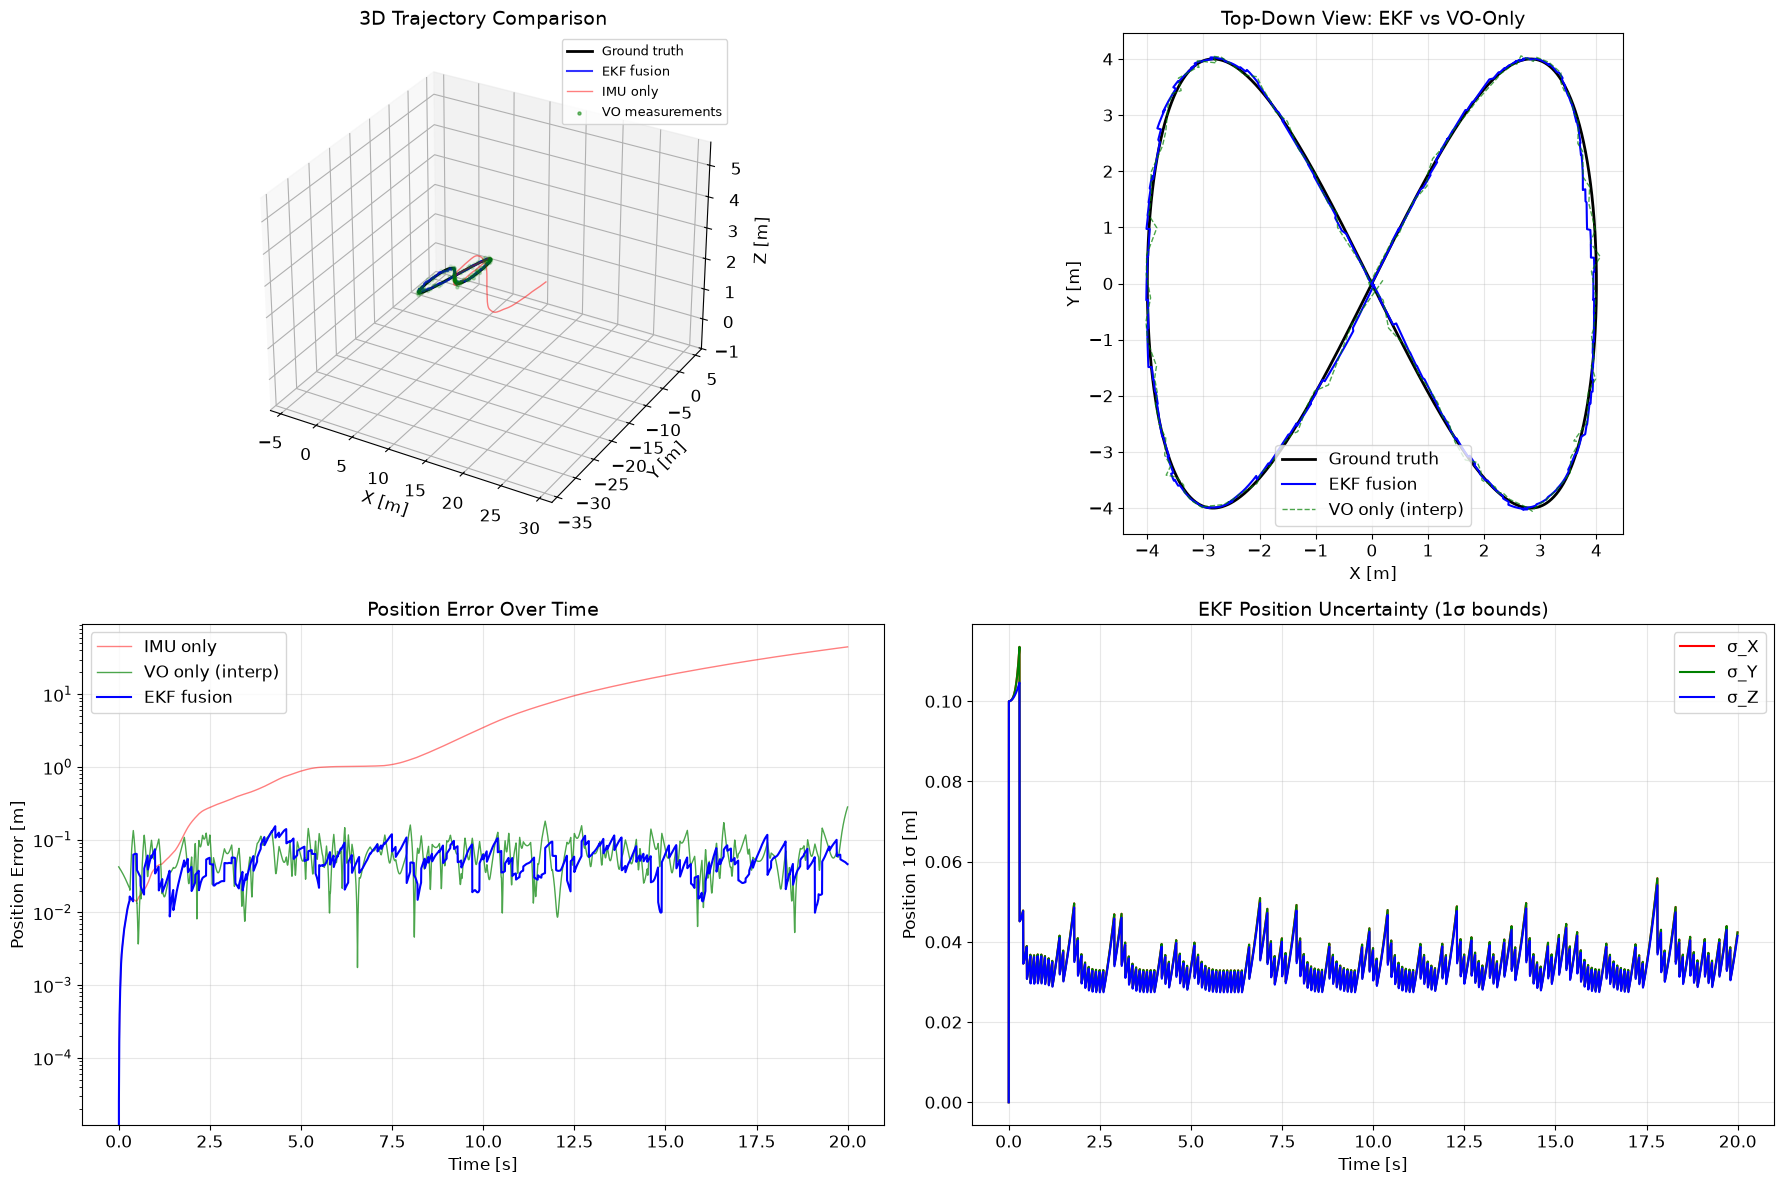


RMSE comparison:
  IMU only:   16.588 m
  VO only:    0.072 m
  EKF fusion: 0.0600 m


In [9]:
# ── Comprehensive comparison plot ────────────────────────────────────

fig = plt.figure(figsize=(18, 12))

# 3D trajectory
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], 'k-', lw=2, label='Ground truth')
ax1.plot(ekf_positions[:, 0], ekf_positions[:, 1], ekf_positions[:, 2],
         'b-', lw=1.5, alpha=0.8, label='EKF fusion')
ax1.plot(dr_pos[:, 0], dr_pos[:, 1], dr_pos[:, 2],
         'r-', lw=1, alpha=0.5, label='IMU only')
ax1.scatter(vo_positions[:, 0], vo_positions[:, 1], vo_positions[:, 2],
            c='g', s=5, alpha=0.5, label='VO measurements')
ax1.set_xlabel('X [m]')
ax1.set_ylabel('Y [m]')
ax1.set_zlabel('Z [m]')
ax1.set_title('3D Trajectory Comparison')
ax1.legend(fontsize=9)

# Top-down XY
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', lw=2, label='Ground truth')
ax2.plot(ekf_positions[:, 0], ekf_positions[:, 1], 'b-', lw=1.5, label='EKF fusion')
ax2.plot(vo_only_pos[:, 0], vo_only_pos[:, 1], 'g--', lw=1, alpha=0.7, label='VO only (interp)')
ax2.set_xlabel('X [m]')
ax2.set_ylabel('Y [m]')
ax2.set_title('Top-Down View: EKF vs VO-Only')
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# Position errors
ax3 = fig.add_subplot(2, 2, 3)
err_ekf = np.linalg.norm(ekf_positions - gt_pos, axis=1)
err_dr = np.linalg.norm(dr_pos - gt_pos, axis=1)
err_vo = np.linalg.norm(vo_only_pos - gt_pos, axis=1)

ax3.plot(t_imu, err_dr, 'r-', lw=1, alpha=0.5, label='IMU only')
ax3.plot(t_imu, err_vo, 'g-', lw=1, alpha=0.7, label='VO only (interp)')
ax3.plot(t_imu, err_ekf, 'b-', lw=1.5, label='EKF fusion')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Position Error [m]')
ax3.set_title('Position Error Over Time')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# EKF position uncertainty (1σ)
ax4 = fig.add_subplot(2, 2, 4)
for dim, label, color in zip(range(3), ['X', 'Y', 'Z'], ['r', 'g', 'b']):
    ax4.plot(t_imu, ekf_pos_std[:, dim], color=color, lw=1.5, label=f'σ_{label}')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Position 1σ [m]')
ax4.set_title('EKF Position Uncertainty (1σ bounds)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRMSE comparison:")
print(f"  IMU only:   {np.sqrt(np.mean(err_dr**2)):.3f} m")
print(f"  VO only:    {np.sqrt(np.mean(err_vo**2)):.3f} m")
print(f"  EKF fusion: {np.sqrt(np.mean(err_ekf**2)):.4f} m")

---

## 4b. Complementary Filter — A Simpler Alternative

Before moving to the more advanced preintegration machinery, it is worth studying the
**complementary filter** — a simpler, elegant approach to attitude estimation that
illuminates *why* sensor fusion works.

### Key Insight: Frequency-Domain Complementarity

The gyroscope and accelerometer have **complementary** noise characteristics:

| Sensor | Short-term | Long-term |
|:---|:---|:---|
| **Gyroscope** | Accurate (integrates angular velocity) | Drifts (bias accumulates) |
| **Accelerometer** | Noisy (contaminated by dynamic acceleration) | Accurate (measures gravity direction) |

A complementary filter exploits this by applying a **high-pass filter** to the
gyroscope (trust it at high frequencies) and a **low-pass filter** to the
accelerometer (trust it at low frequencies).

### Mathematical Formulation

Consider estimating a single attitude angle $\theta$ (e.g., pitch).  The gyroscope
gives angular velocity $\omega$ (integrate for angle), while the accelerometer gives
a noisy but drift-free angle estimate $\theta_{\text{acc}}$ (from the gravity direction).

**Continuous time (Laplace domain):**

$$
\hat{\theta}(s) = \underbrace{\frac{\tau s}{1 + \tau s}}_{\text{high-pass}} \cdot \frac{\omega(s)}{s}
\;+\; \underbrace{\frac{1}{1 + \tau s}}_{\text{low-pass}} \cdot \theta_{\text{acc}}(s)
$$

where $\tau$ is the filter **time constant** (crossover frequency $f_c = 1/(2\pi\tau)$).

The two transfer functions sum to unity for all $s$:

$$
\frac{\tau s}{1 + \tau s} + \frac{1}{1 + \tau s} = 1
$$

Hence the name "complementary" — the two filters together reconstruct the full spectrum.

**Discrete time:**  Euler discretization with time step $\Delta t$ gives the
one-line update rule:

$$
\boxed{\hat{\theta}_k = \alpha \bigl(\hat{\theta}_{k-1} + \omega_k \,\Delta t\bigr) + (1 - \alpha)\,\theta_{\text{acc},k}}
$$

where $\alpha = \frac{\tau}{\tau + \Delta t} \in (0, 1)$.

- When $\alpha \to 1$: trust the gyroscope almost exclusively (large $\tau$)
- When $\alpha \to 0$: trust the accelerometer almost exclusively (small $\tau$)
- Typical values: $\alpha \in [0.95, 0.99]$ for consumer IMUs at 100–200 Hz

### Extracting Attitude from the Accelerometer

When the sensor is (approximately) stationary or in uniform motion, the
accelerometer reading $\mathbf{a}_m \approx -R^\top \mathbf{g}$ points opposite
to gravity in the body frame.  The pitch and roll angles follow from:

$$
\theta_{\text{pitch}} = \arctan\!\left(\frac{a_x}{\sqrt{a_y^2 + a_z^2}}\right), \qquad
\theta_{\text{roll}} = \arctan2(a_y,\; a_z)
$$

**Limitation:** The accelerometer cannot distinguish gravity from dynamic
acceleration, so $\theta_{\text{acc}}$ is unreliable during aggressive maneuvers.
The high $\alpha$ ensures the gyroscope dominates during transients.

**Yaw is unobservable** from the accelerometer alone (gravity has no horizontal
component), so a magnetometer is needed for a full 3-axis complementary filter.

### Relation to the Kalman Filter

The complementary filter is a **special case** of the steady-state Kalman filter
for the system:

$$
\dot{\theta} = \omega + n_g, \qquad z = \theta + n_a
$$

with process noise $n_g$ (gyroscope drift) and measurement noise $n_a$
(accelerometer noise).  The steady-state Kalman gain $K_\infty$ satisfies:

$$
\alpha = 1 - K_\infty
$$

So choosing $\alpha$ is equivalent to choosing the noise ratio
$\sigma_g^2 / \sigma_a^2$ in a Kalman filter.  The advantage of the complementary
filter is that it requires **no covariance propagation** — just one line of code.

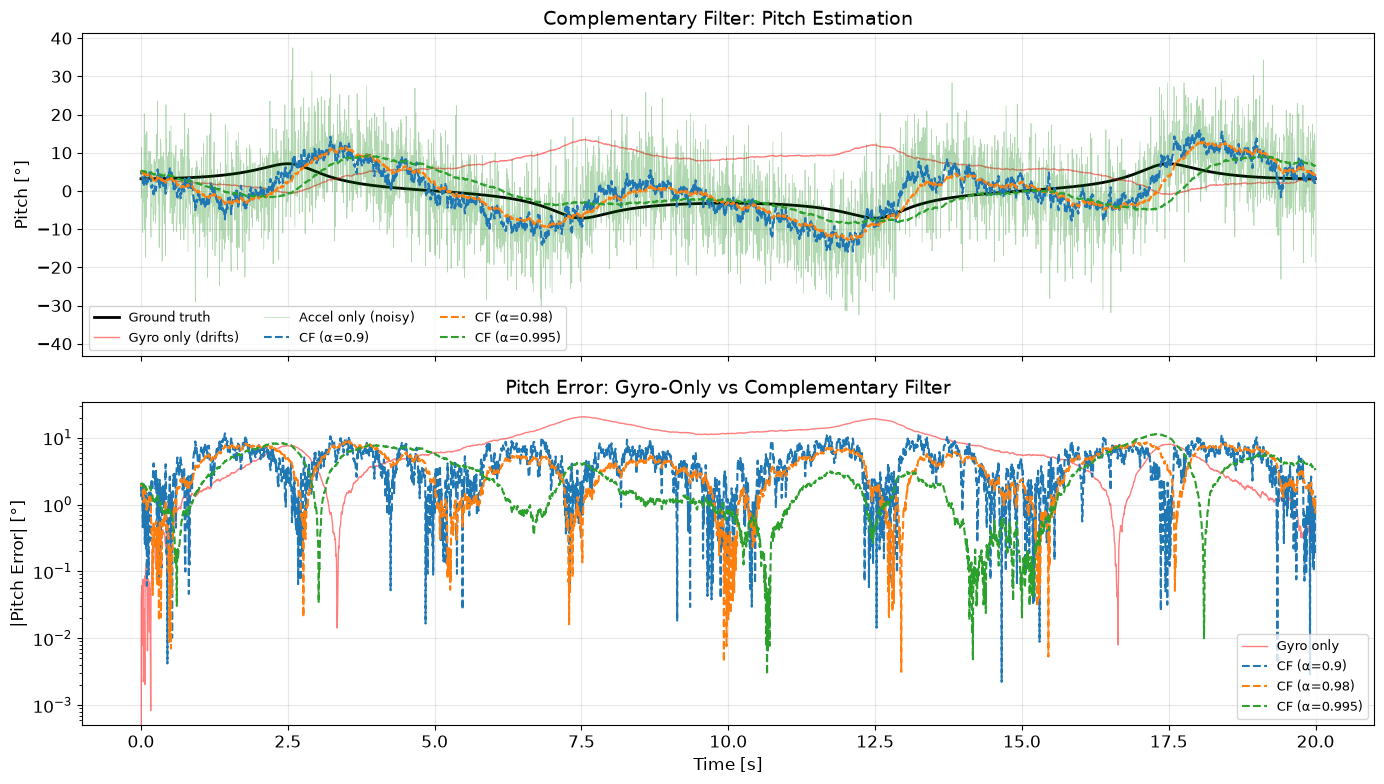

Pitch RMSE — Gyro only: 9.68°, CF (α=0.98): 4.60°


In [10]:
# ── Complementary filter demonstration ────────────────────────────────

def complementary_filter(accel_data, gyro_data, dt, alpha=0.98):
    """Complementary filter for roll and pitch estimation.

    Parameters
    ----------
    accel_data : (N, 3) accelerometer readings
    gyro_data  : (N, 3) gyroscope readings
    dt         : float, sampling period
    alpha      : float, filter constant in (0, 1)

    Returns
    -------
    roll, pitch : (N,) arrays in radians
    """
    N = len(accel_data)
    roll = np.zeros(N)
    pitch = np.zeros(N)

    # Initialize from accelerometer
    a = accel_data[0]
    pitch[0] = np.arctan2(a[0], np.sqrt(a[1]**2 + a[2]**2))
    roll[0] = np.arctan2(a[1], a[2])

    for k in range(1, N):
        # Gyroscope integration (high-frequency trust)
        roll_gyro = roll[k-1] + gyro_data[k, 0] * dt
        pitch_gyro = pitch[k-1] + gyro_data[k, 1] * dt

        # Accelerometer angle (low-frequency trust)
        a = accel_data[k]
        pitch_acc = np.arctan2(a[0], np.sqrt(a[1]**2 + a[2]**2))
        roll_acc = np.arctan2(a[1], a[2])

        # Complementary fusion
        roll[k] = alpha * roll_gyro + (1 - alpha) * roll_acc
        pitch[k] = alpha * pitch_gyro + (1 - alpha) * pitch_acc

    return roll, pitch


# Run on our synthetic IMU data
alphas = [0.90, 0.98, 0.995]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Ground-truth pitch from the figure-8 trajectory
gt_pitch = np.arctan2(gt_vel[:, 2], np.sqrt(gt_vel[:, 0]**2 + gt_vel[:, 1]**2))

# Gyro-only integration (drifts)
gyro_pitch = np.zeros(N_imu)
gyro_pitch[0] = gt_pitch[0]
for k in range(1, N_imu):
    gyro_pitch[k] = gyro_pitch[k-1] + imu_gyro[k, 1] * dt_imu

# Accel-only angle (noisy)
accel_pitch = np.arctan2(imu_accel[:, 0],
                          np.sqrt(imu_accel[:, 1]**2 + imu_accel[:, 2]**2))

axes[0].plot(t_imu, np.rad2deg(gt_pitch), 'k-', lw=2, label='Ground truth')
axes[0].plot(t_imu, np.rad2deg(gyro_pitch), 'r-', lw=1, alpha=0.5,
             label='Gyro only (drifts)')
axes[0].plot(t_imu, np.rad2deg(accel_pitch), 'g-', lw=0.5, alpha=0.3,
             label='Accel only (noisy)')
for alpha_val in alphas:
    _, cf_pitch = complementary_filter(imu_accel, imu_gyro, dt_imu, alpha=alpha_val)
    axes[0].plot(t_imu, np.rad2deg(cf_pitch), '--', lw=1.5,
                 label=f'CF (α={alpha_val})')

axes[0].set_ylabel('Pitch [°]')
axes[0].set_title('Complementary Filter: Pitch Estimation')
axes[0].legend(fontsize=9, ncol=3)
axes[0].grid(True, alpha=0.3)

# Error comparison
axes[1].plot(t_imu, np.abs(np.rad2deg(gyro_pitch - gt_pitch)), 'r-', lw=1,
             alpha=0.5, label='Gyro only')
for alpha_val in alphas:
    _, cf_pitch = complementary_filter(imu_accel, imu_gyro, dt_imu, alpha=alpha_val)
    axes[1].plot(t_imu, np.abs(np.rad2deg(cf_pitch - gt_pitch)), '--', lw=1.5,
                 label=f'CF (α={alpha_val})')

axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('|Pitch Error| [°]')
axes[1].set_title('Pitch Error: Gyro-Only vs Complementary Filter')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Compute RMSE for best alpha
_, cf_best = complementary_filter(imu_accel, imu_gyro, dt_imu, alpha=0.98)
rmse_gyro = np.sqrt(np.mean((gyro_pitch - gt_pitch)**2))
rmse_cf = np.sqrt(np.mean((cf_best - gt_pitch)**2))
print(f"Pitch RMSE — Gyro only: {np.rad2deg(rmse_gyro):.2f}°, "
      f"CF (α=0.98): {np.rad2deg(rmse_cf):.2f}°")

---

## 5. IMU Preintegration

### 5.1 Motivation

In graph-based VIO, we need to express the constraint between two keyframes $i$ and $j$
from all the IMU measurements in between.  A naïve approach would re-integrate all IMU
data from $i$ to $j$ every time the state at $i$ changes during optimization.  This is
prohibitively expensive.

**Preintegration** (Lupton & Sukkarieh 2012, refined by Forster et al. 2017) solves this
by computing IMU integrals in a **reference frame anchored at keyframe $i$**, so they
are independent of the state at $i$ (except for bias, handled by first-order correction).

### 5.2 Preintegrated Measurements on $\text{SO}(3)$

Between keyframes $i$ and $j$ (with IMU samples $k = i, i+1, \ldots, j-1$), define:

#### Rotation preintegral

$$
\boxed{
\Delta R_{ij} = \prod_{k=i}^{j-1} \text{Exp}\bigl((\boldsymbol{\omega}_k - \mathbf{b}_g) \Delta t\bigr)
}
$$

This is a product of incremental rotations on $\text{SO}(3)$.  The $\text{Exp}$ map converts
each bias-corrected angular velocity sample into a rotation matrix:

$$
\text{Exp}(\boldsymbol{\phi}) = I + \frac{\sin\|\boldsymbol{\phi}\|}{\|\boldsymbol{\phi}\|}[\boldsymbol{\phi}]_\times
+ \frac{1 - \cos\|\boldsymbol{\phi}\|}{\|\boldsymbol{\phi}\|^2}[\boldsymbol{\phi}]_\times^2
$$

The incremental rotation is:

$$
\Delta R_{i,k+1} = \Delta R_{ik} \cdot \text{Exp}\bigl((\boldsymbol{\omega}_k - \mathbf{b}_g)\Delta t\bigr)
$$

with $\Delta R_{ii} = I$.

#### Velocity preintegral

$$
\boxed{
\Delta \mathbf{v}_{ij} = \sum_{k=i}^{j-1} \Delta R_{ik} (\mathbf{a}_k - \mathbf{b}_a) \Delta t
}
$$

**Derivation:** In the world frame, $\dot{\mathbf{v}} = R_k(\mathbf{a}_k - \mathbf{b}_a) + \mathbf{g}$.
Subtracting gravity and transforming to the reference frame at $i$:

$$
\mathbf{v}_j - \mathbf{v}_i - \mathbf{g}\Delta t_{ij} = R_i \sum_{k=i}^{j-1} \Delta R_{ik}(\mathbf{a}_k - \mathbf{b}_a)\Delta t
= R_i \, \Delta\mathbf{v}_{ij}
$$

#### Position preintegral

$$
\boxed{
\Delta \mathbf{p}_{ij} = \sum_{k=i}^{j-1} \left( \Delta \mathbf{v}_{ik} \Delta t + \tfrac{1}{2} \Delta R_{ik} (\mathbf{a}_k - \mathbf{b}_a) \Delta t^2 \right)
}
$$

**Derivation:** Starting from $\mathbf{p}_j - \mathbf{p}_i - \mathbf{v}_i \Delta t_{ij} - \tfrac{1}{2}\mathbf{g}\Delta t_{ij}^2 = R_i \, \Delta\mathbf{p}_{ij}$,
discretize and collect terms.

### 5.3 First-Order Bias Correction

When biases $\mathbf{b}_a, \mathbf{b}_g$ are updated during optimization, we do **not** need
to re-integrate.  Instead, we apply a first-order Taylor correction:

$$
\Delta R_{ij}(\mathbf{b}_g + \delta\mathbf{b}_g) \approx \Delta R_{ij}(\mathbf{b}_g) \cdot \text{Exp}\!\left(\frac{\partial \Delta R_{ij}}{\partial \mathbf{b}_g} \delta\mathbf{b}_g\right)
$$

$$
\Delta \mathbf{v}_{ij}(\mathbf{b}_a + \delta\mathbf{b}_a, \mathbf{b}_g + \delta\mathbf{b}_g)
\approx \Delta\mathbf{v}_{ij} + \frac{\partial \Delta\mathbf{v}_{ij}}{\partial \mathbf{b}_a}\delta\mathbf{b}_a
+ \frac{\partial \Delta\mathbf{v}_{ij}}{\partial \mathbf{b}_g}\delta\mathbf{b}_g
$$

$$
\Delta \mathbf{p}_{ij}(\mathbf{b}_a + \delta\mathbf{b}_a, \mathbf{b}_g + \delta\mathbf{b}_g)
\approx \Delta\mathbf{p}_{ij} + \frac{\partial \Delta\mathbf{p}_{ij}}{\partial \mathbf{b}_a}\delta\mathbf{b}_a
+ \frac{\partial \Delta\mathbf{p}_{ij}}{\partial \mathbf{b}_g}\delta\mathbf{b}_g
$$

The Jacobians $\frac{\partial \Delta R}{\partial \mathbf{b}_g}$, $\frac{\partial \Delta\mathbf{v}}{\partial \mathbf{b}_a}$,
$\frac{\partial \Delta\mathbf{v}}{\partial \mathbf{b}_g}$, etc. are accumulated recursively
during preintegration.  For example:

$$
\frac{\partial \Delta R_{i,k+1}}{\partial \mathbf{b}_g}
= -J_r\bigl((\boldsymbol{\omega}_k - \mathbf{b}_g)\Delta t\bigr) \Delta t
+ \text{Exp}\bigl(-(\boldsymbol{\omega}_k - \mathbf{b}_g)\Delta t\bigr) \frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g}
$$

> **Derivation via BCH approximation:**
>
> Starting from $\Delta R_{i,k+1} = \Delta R_{ik} \cdot \text{Exp}(\boldsymbol{\phi}_k \Delta t)$ where $\boldsymbol{\phi}_k = \boldsymbol{\omega}_k - \mathbf{b}_g$:
>
> Perturb $\mathbf{b}_g \to \mathbf{b}_g + \delta\mathbf{b}_g$, so $\boldsymbol{\phi}_k \to \boldsymbol{\phi}_k - \delta\mathbf{b}_g$:
>
> $$\Delta R_{i,k+1}' = \Delta R_{ik}' \cdot \text{Exp}((\boldsymbol{\phi}_k - \delta\mathbf{b}_g) \Delta t)$$
>
> Using the right-Jacobian identity $\text{Exp}(\boldsymbol{\phi} + \delta\boldsymbol{\phi}) \approx \text{Exp}(\boldsymbol{\phi}) \cdot \text{Exp}(J_r(\boldsymbol{\phi}) \cdot \delta\boldsymbol{\phi})$:
>
> $$\text{Exp}((\boldsymbol{\phi}_k - \delta\mathbf{b}_g)\Delta t) \approx \text{Exp}(\boldsymbol{\phi}_k \Delta t) \cdot \text{Exp}(-J_r(\boldsymbol{\phi}_k \Delta t) \cdot \delta\mathbf{b}_g \cdot \Delta t)$$
>
> Substituting:
>
> $$\Delta R_{i,k+1}' \approx \Delta R_{ik}' \cdot \text{Exp}(\boldsymbol{\phi}_k \Delta t) \cdot \text{Exp}(-J_r(\boldsymbol{\phi}_k \Delta t) \Delta t \cdot \delta\mathbf{b}_g)$$
>
> Now $\Delta R_{ik}' \approx \Delta R_{ik} \cdot \text{Exp}\!\left(\frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g} \delta\mathbf{b}_g\right)$, so moving the perturbation through:
>
> $$\Delta R_{i,k+1}' \approx \Delta R_{ik} \cdot \text{Exp}\!\left(\frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g}\delta\mathbf{b}_g\right) \cdot \text{Exp}(\boldsymbol{\phi}_k \Delta t) \cdot \text{Exp}(-J_r \Delta t \cdot \delta\mathbf{b}_g)$$
>
> Using the adjoint identity $\text{Exp}(\delta) \cdot R = R \cdot \text{Exp}(R^\top \delta)$ to move the first perturbation past $\text{Exp}(\boldsymbol{\phi}_k \Delta t)$, and combining the two small-angle exponentials:
>
> $$\frac{\partial \Delta R_{i,k+1}}{\partial \mathbf{b}_g} = \text{Exp}(-\boldsymbol{\phi}_k \Delta t) \cdot \frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g} - J_r(\boldsymbol{\phi}_k \Delta t) \Delta t$$

where $J_r(\boldsymbol{\phi})$ is the right Jacobian of $\text{SO}(3)$:

$$
J_r(\boldsymbol{\phi}) = I - \frac{1 - \cos\|\boldsymbol{\phi}\|}{\|\boldsymbol{\phi}\|^2}[\boldsymbol{\phi}]_\times
+ \frac{\|\boldsymbol{\phi}\| - \sin\|\boldsymbol{\phi}\|}{\|\boldsymbol{\phi}\|^3}[\boldsymbol{\phi}]_\times^2
$$

### 5.4 Velocity and Position Bias Jacobians

The first-order bias correction in §5.3 requires the Jacobians of $\Delta\mathbf{v}$ and $\Delta\mathbf{p}$
with respect to the accelerometer bias $\mathbf{b}_a$ and gyroscope bias $\mathbf{b}_g$.
These follow directly from differentiating the discrete preintegration sums for
$\Delta\mathbf{v}$ and $\Delta\mathbf{p}$ with respect to the biases.

All four Jacobians are $3\times 3$ matrices initialized to zero at $k = i$, and are
accumulated recursively alongside the preintegrated measurements.

---

#### Velocity Jacobian with respect to accelerometer bias

$$
\boxed{
\frac{\partial \Delta\mathbf{v}_{i,k+1}}{\partial \mathbf{b}_a}
= \frac{\partial \Delta\mathbf{v}_{ik}}{\partial \mathbf{b}_a}
  - \Delta R_{ik} \, \Delta t
}
$$

This comes from differentiating $\Delta\mathbf{v}_{i,k+1} = \Delta\mathbf{v}_{ik} + \Delta R_{ik}(\mathbf{a}_k - \mathbf{b}_a)\Delta t$
with respect to $\mathbf{b}_a$.  Since $\Delta R_{ik}$ does not depend on $\mathbf{b}_a$,
only the $(-\mathbf{b}_a)$ term contributes.

#### Velocity Jacobian with respect to gyroscope bias

$$
\boxed{
\frac{\partial \Delta\mathbf{v}_{i,k+1}}{\partial \mathbf{b}_g}
= \frac{\partial \Delta\mathbf{v}_{ik}}{\partial \mathbf{b}_g}
  - \Delta R_{ik} \, [\mathbf{a}_k - \mathbf{b}_a]_\times \,
    \frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g} \, \Delta t
}
$$

Here $\Delta R_{ik}$ depends on $\mathbf{b}_g$.  To see where $[\mathbf{a}_k - \mathbf{b}_a]_\times$ comes from,
let $\mathbf{a} = \mathbf{a}_k - \mathbf{b}_a$ and perturb $\Delta R \to \Delta R \cdot \text{Exp}(\delta\boldsymbol{\phi})$ with
$\delta\boldsymbol{\phi} = \frac{\partial \Delta R}{\partial \mathbf{b}_g} \delta\mathbf{b}_g$:

$$
\Delta R \cdot (I + [\delta\boldsymbol{\phi}]_\times) \cdot \mathbf{a}
= \Delta R\,\mathbf{a} + \Delta R\,[\delta\boldsymbol{\phi}]_\times\,\mathbf{a}
= \Delta R\,\mathbf{a} - \Delta R\,[\mathbf{a}]_\times\,\delta\boldsymbol{\phi}
$$

where we used the cross-product identity $[\delta\boldsymbol{\phi}]_\times \mathbf{a} = -[\mathbf{a}]_\times \delta\boldsymbol{\phi}$.
This gives $\frac{\partial(\Delta R\,\mathbf{a})}{\partial \mathbf{b}_g} = -\Delta R\,[\mathbf{a}]_\times\,\frac{\partial \Delta R}{\partial \mathbf{b}_g}$,
which is the term in the boxed formula above.

---

#### Position Jacobian with respect to accelerometer bias

$$
\boxed{
\frac{\partial \Delta\mathbf{p}_{i,k+1}}{\partial \mathbf{b}_a}
= \frac{\partial \Delta\mathbf{p}_{ik}}{\partial \mathbf{b}_a}
  + \frac{\partial \Delta\mathbf{v}_{ik}}{\partial \mathbf{b}_a} \, \Delta t
  - \tfrac{1}{2} \, \Delta R_{ik} \, \Delta t^2
}
$$

From the position update $\Delta\mathbf{p}_{i,k+1} = \Delta\mathbf{p}_{ik} + \Delta\mathbf{v}_{ik}\Delta t + \tfrac{1}{2}\Delta R_{ik}(\mathbf{a}_k - \mathbf{b}_a)\Delta t^2$,
differentiating with respect to $\mathbf{b}_a$ gives one term from $\Delta\mathbf{v}_{ik}$
(via the chain rule) and a direct term from the acceleration integral.

#### Position Jacobian with respect to gyroscope bias

$$
\boxed{
\frac{\partial \Delta\mathbf{p}_{i,k+1}}{\partial \mathbf{b}_g}
= \frac{\partial \Delta\mathbf{p}_{ik}}{\partial \mathbf{b}_g}
  + \frac{\partial \Delta\mathbf{v}_{ik}}{\partial \mathbf{b}_g} \, \Delta t
  - \tfrac{1}{2} \, \Delta R_{ik} \, [\mathbf{a}_k - \mathbf{b}_a]_\times \,
    \frac{\partial \Delta R_{ik}}{\partial \mathbf{b}_g} \, \Delta t^2
}
$$

The structure mirrors $\frac{\partial \Delta\mathbf{v}}{\partial \mathbf{b}_g}$: the
$\Delta\mathbf{v}_{ik}$ term contributes through the chain rule, and the
$\tfrac{1}{2}\Delta R_{ik}(\mathbf{a}_k - \mathbf{b}_a)\Delta t^2$ term produces the
same skew-symmetric factor.

---

**Initial conditions ($k = i$):**

$$
\frac{\partial \Delta\mathbf{v}_{ii}}{\partial \mathbf{b}_a} = \mathbf{0}_{3\times 3}, \quad
\frac{\partial \Delta\mathbf{v}_{ii}}{\partial \mathbf{b}_g} = \mathbf{0}_{3\times 3}, \quad
\frac{\partial \Delta\mathbf{p}_{ii}}{\partial \mathbf{b}_a} = \mathbf{0}_{3\times 3}, \quad
\frac{\partial \Delta\mathbf{p}_{ii}}{\partial \mathbf{b}_g} = \mathbf{0}_{3\times 3}
$$

In [11]:
# ── IMU Preintegration demonstration ─────────────────────────────────

def skew(v):
    """3x3 skew-symmetric matrix."""
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])

def so3_exp(phi):
    """Exponential map SO(3): rotation vector → rotation matrix."""
    angle = np.linalg.norm(phi)
    if angle < 1e-10:
        return np.eye(3) + skew(phi)
    axis = phi / angle
    K = skew(axis)
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K

def so3_log(R):
    """Logarithm map SO(3): rotation matrix → rotation vector."""
    cos_angle = np.clip((np.trace(R) - 1) / 2, -1, 1)
    angle = np.arccos(cos_angle)
    if angle < 1e-10:
        return np.zeros(3)
    return angle / (2 * np.sin(angle)) * np.array([R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]])


def preintegrate(accel_measurements, gyro_measurements, ba, bg, dt):
    """
    Preintegrate IMU measurements between two keyframes.

    Returns: delta_R, delta_v, delta_p (all in the local reference frame)
    """
    N = len(accel_measurements)
    delta_R = np.eye(3)
    delta_v = np.zeros(3)
    delta_p = np.zeros(3)

    for k in range(N):
        a_corrected = accel_measurements[k] - ba
        w_corrected = gyro_measurements[k] - bg

        delta_p += delta_v * dt + 0.5 * delta_R @ a_corrected * dt**2
        delta_v += delta_R @ a_corrected * dt
        delta_R = delta_R @ so3_exp(w_corrected * dt)

    return delta_R, delta_v, delta_p


# Preintegrate between keyframes spaced 0.5s apart
kf_interval = 0.5  # seconds
kf_samples = int(kf_interval / dt_imu)
n_keyframes = int(T_total / kf_interval)

preint_positions = [gt_pos[0].copy()]
preint_pos = gt_pos[0].copy()
preint_vel = gt_vel[0].copy()
preint_R = Rotation.from_quat([gt_quats[0, 1], gt_quats[0, 2],
                                gt_quats[0, 3], gt_quats[0, 0]]).as_matrix()

ba_est = np.zeros(3)  # assume zero bias estimate
bg_est = np.zeros(3)

for kf in range(n_keyframes - 1):
    start = kf * kf_samples
    end = start + kf_samples
    if end > N_imu:
        break

    dR, dv, dp = preintegrate(
        imu_accel[start:end], imu_gyro[start:end], ba_est, bg_est, dt_imu
    )

    dt_kf = kf_interval
    preint_pos = (preint_pos + preint_vel * dt_kf
                  + 0.5 * gravity * dt_kf**2
                  + preint_R @ dp)
    preint_vel = preint_vel + gravity * dt_kf + preint_R @ dv
    preint_R = preint_R @ dR

    preint_positions.append(preint_pos.copy())

preint_positions = np.array(preint_positions)

print(f"Preintegrated {n_keyframes} keyframes at {kf_interval}s intervals")
print(f"Final preintegrated position error: "
      f"{np.linalg.norm(preint_positions[-1] - gt_pos[min((n_keyframes-1)*kf_samples, N_imu-1)]):.2f} m")

Preintegrated 40 keyframes at 0.5s intervals
Final preintegrated position error: 41.56 m


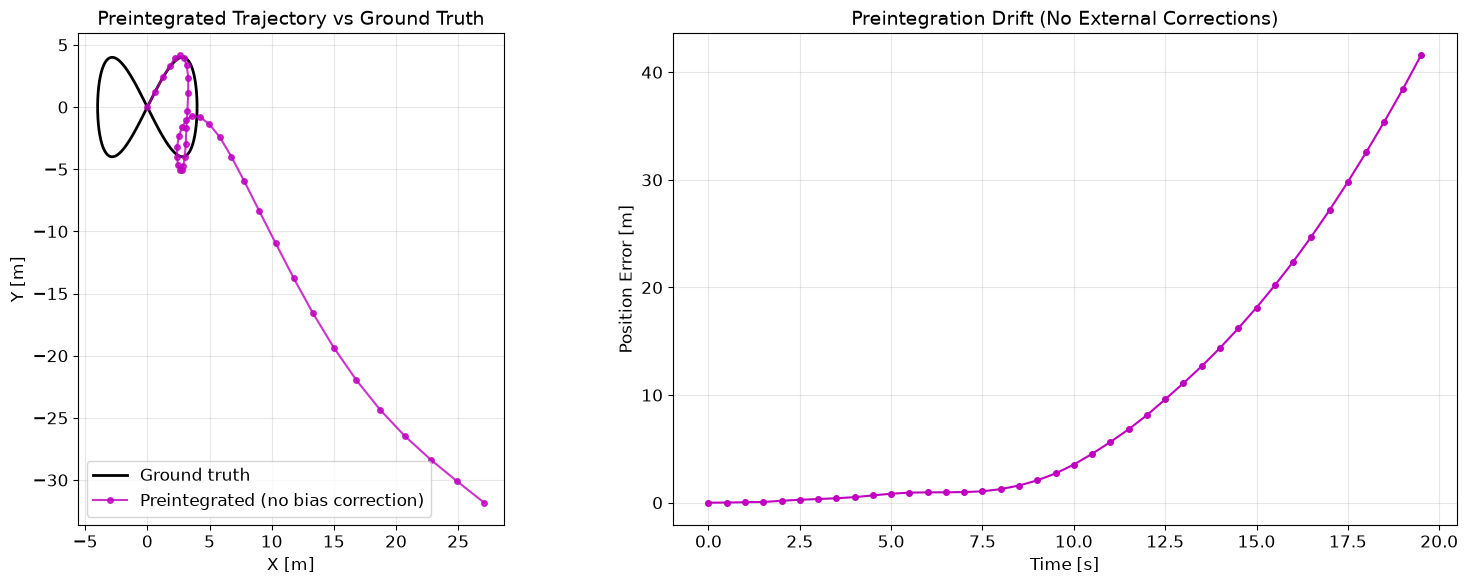

In [12]:
# ── Plot preintegrated trajectory ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

kf_times = np.arange(n_keyframes) * kf_interval
kf_gt = gt_pos[::kf_samples][:n_keyframes]

axes[0].plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', lw=2, label='Ground truth')
axes[0].plot(preint_positions[:, 0], preint_positions[:, 1], 'mo-', lw=1.5,
             ms=4, alpha=0.8, label='Preintegrated (no bias correction)')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Y [m]')
axes[0].set_title('Preintegrated Trajectory vs Ground Truth')
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# Position error at keyframes
min_len = min(len(preint_positions), len(kf_gt))
preint_err = np.linalg.norm(preint_positions[:min_len] - kf_gt[:min_len], axis=1)

axes[1].plot(kf_times[:min_len], preint_err, 'mo-', lw=1.5, ms=4)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Position Error [m]')
axes[1].set_title('Preintegration Drift (No External Corrections)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Factor Graphs vs EKF

The EKF we derived above is a **fixed-lag** estimator: it maintains a single state estimate
and covariance, marginalizing out all past states.  This has important limitations.

### 6.1 EKF Limitations

| Issue | Description |
|:---|:---|
| **Linearization error** | The EKF linearizes about the current estimate. If the initial linearization point is poor, the filter can converge to the wrong solution. |
| **No relinearization** | Past measurements cannot be reprocessed with an improved linearization point. |
| **No loop closure** | When a previously visited place is recognized, the EKF cannot correct past states. |
| **Marginalization damage** | Information about past states is compressed into a single Gaussian, losing correlations. |

### 6.2 Factor Graph Formulation

A **factor graph** maintains the full trajectory as variables $\{\mathbf{x}_0, \mathbf{x}_1, \ldots, \mathbf{x}_n\}$
and encodes measurements as **factors** (probabilistic constraints):

$$
\mathbf{x}^* = \arg\min_{\mathbf{x}} \sum_k \|\mathbf{e}_k(\mathbf{x})\|^2_{\Sigma_k}
$$

where $\|\mathbf{e}\|^2_\Sigma = \mathbf{e}^\top \Sigma^{-1} \mathbf{e}$ is the Mahalanobis norm.

**Factor types in VIO:**

1. **IMU preintegration factor** between consecutive keyframes:

$$
\mathbf{e}_{\text{IMU}}(\mathbf{x}_i, \mathbf{x}_j) = \begin{bmatrix}
R_i^\top(\mathbf{p}_j - \mathbf{p}_i - \mathbf{v}_i \Delta t - \tfrac{1}{2}\mathbf{g}\Delta t^2) - \Delta\hat{\mathbf{p}}_{ij} \\
R_i^\top(\mathbf{v}_j - \mathbf{v}_i - \mathbf{g}\Delta t) - \Delta\hat{\mathbf{v}}_{ij} \\
\text{Log}(\Delta\hat{R}_{ij}^\top R_i^\top R_j)
\end{bmatrix}
$$

2. **Visual reprojection factor** for each landmark observation:

$$
\mathbf{e}_{\text{vis}}(\mathbf{x}_k, \mathbf{l}_m) = \mathbf{z}_{km} - \pi(R_k^\top(\mathbf{l}_m - \mathbf{p}_k))
$$

where $\pi$ is the camera projection function.

3. **Prior factor** on the initial state.

### 6.3 iSAM2: Incremental Optimization

**iSAM2** (Kaess et al., 2012) maintains a Bayes tree representation of the factor graph,
enabling:

- **Incremental updates**: Only the affected part of the tree is recomputed when new factors arrive.
- **Relinearization**: Variables can be relinearized when their estimate changes significantly.
- **Fluid relinearization**: The threshold for relinearization can be tuned per variable.

The Bayes tree converts the sparse linear system $H\delta\mathbf{x} = \mathbf{b}$ (from
Gauss-Newton) into a sequence of back-substitutions, achieving $O(n)$ incremental updates
for typical VIO factor graphs.

### 6.4 Comparison Summary

| Property | EKF | Factor Graph (iSAM2) |
|:---|:---|:---|
| State history | Current only | Full trajectory |
| Relinearization | No | Yes |
| Loop closure | Difficult | Natural |
| Computational cost | $O(n^2)$ per step | $O(n)$ amortized |
| Implementation | Simple | Complex (GTSAM, Ceres) |

---

## 7. Continuous-Time Trajectories

Both EKF and factor graphs model the trajectory as **discrete** poses at specific times.
An alternative paradigm represents the trajectory as a **continuous function of time**.

### 7.1 B-Spline Trajectories

A **cumulative cubic B-spline** on $\text{SE}(3)$ parameterizes the trajectory using
control poses $\{T_i\}$ at uniform knot times $\{t_i\}$:

$$
T(u) = T_i \prod_{j=1}^{3} \text{Exp}\!\left( \tilde{B}_j(u) \cdot \text{Log}(T_{i+j-1}^{-1} T_{i+j}) \right)
$$

where $u \in [0,1)$ is the normalized time within the knot span and $\tilde{B}_j(u)$ are
cumulative basis functions derived from the standard B-spline basis matrix:

$$
M = \frac{1}{6}\begin{bmatrix} 1 & 4 & 1 & 0 \\ -3 & 0 & 3 & 0 \\ 3 & -6 & 3 & 0 \\ -1 & 3 & -3 & 1 \end{bmatrix}
$$

**Advantages:**
- Naturally handles measurements at arbitrary times (no interpolation needed)
- Derivatives (velocity, acceleration) are analytic — can directly compare with IMU
- $C^2$ continuity is guaranteed by the B-spline construction

### 7.2 Gaussian Process Trajectories

A **Gaussian Process** (GP) prior models the trajectory as a sample from a
stochastic process.  For VIO, the white-noise-on-jerk (WNOJ) prior is common:

$$
\dddot{\mathbf{p}}(t) = \mathbf{w}(t), \quad \mathbf{w}(t) \sim \mathcal{GP}(\mathbf{0}, Q_c \delta(t-t'))
$$

This leads to a state-space model with state $\mathbf{x}(t) = [\mathbf{p}, \dot{\mathbf{p}}, \ddot{\mathbf{p}}]^\top$:

$$
\dot{\mathbf{x}}(t) = \underbrace{\begin{bmatrix} 0 & I & 0 \\ 0 & 0 & I \\ 0 & 0 & 0 \end{bmatrix}}_{A} \mathbf{x}(t)
+ \underbrace{\begin{bmatrix} 0 \\ 0 \\ I \end{bmatrix}}_{B} \mathbf{w}(t)
$$

The GP prior encodes the physical constraint that trajectories should be smooth
(low jerk), while measurements pull the trajectory toward observations.

**Key results:**

The transition matrix and process noise over interval $\Delta t$:

$$
\Phi(\Delta t) = \begin{bmatrix}
I & I\Delta t & \frac{1}{2}I\Delta t^2 \\
0 & I & I\Delta t \\
0 & 0 & I
\end{bmatrix}, \qquad
Q_d(\Delta t) = Q_c \begin{bmatrix}
\frac{\Delta t^5}{20}I & \frac{\Delta t^4}{8}I & \frac{\Delta t^3}{6}I \\
\frac{\Delta t^4}{8}I & \frac{\Delta t^3}{3}I & \frac{\Delta t^2}{2}I \\
\frac{\Delta t^3}{6}I & \frac{\Delta t^2}{2}I & \Delta t \, I
\end{bmatrix}
$$

GP-based VIO (e.g., Anderson et al., STEAM) enables:
- Interpolation of the state at any query time
- Fusion of asynchronous multi-sensor data without pre-alignment
- Principled handling of time offsets between sensors

### 7.3 GPTR — Gaussian Process Trajectory Representation (2024)

**GPTR** extends the GP trajectory idea above with a formulation tailored to
robotics on Lie groups.

**GP prior — white-noise-on-jerk:** Like the WNOJ model in §7.2, GPTR uses a
third-order model where the driving noise acts on jerk:

$$
\dddot{\mathbf{x}}(t) = \mathbf{w}(t), \quad \mathbf{w}(t) \sim \mathcal{GP}(\mathbf{0}, Q_c \delta(t - t'))
$$

but critically, the formulation respects the manifold structure of $SO(3)$ and $SE(3)$.

**Closed-form Lie group kinematics:** Unlike generic GP regression which operates in
Euclidean $\mathbb{R}^n$, GPTR provides **closed-form expressions** for rotational
velocity and acceleration directly on $SO(3)$:

$$
R(t) = R_i \cdot \operatorname{Exp}\!\left(\boldsymbol{\phi}(t)\right), \quad
\boldsymbol{\omega}(t) = J_l^{-1}(\boldsymbol{\phi}) \dot{\boldsymbol{\phi}}(t)
$$

where $J_l^{-1}$ is the inverse left Jacobian of $SO(3)$, ensuring that angular
velocity is correctly mapped between the Lie algebra and the tangent space.

**Analytical Jacobians:** All derivatives needed for optimization (with respect to
control poses and $Q_c$ hyperparameters) are computed in closed form — no finite
differences required. This makes GPTR efficient inside iterative solvers like
Levenberg–Marquardt.

**Results:** Tested on LiDAR-inertial odometry, GPTR achieves accuracy competitive
with discrete-time methods (e.g., factor graphs with preintegrated IMU factors)
while providing smooth, continuously queryable trajectories at any timestamp $t$.

### 7.4 G-solver — GP Trajectories Meet Distributed Estimation (2026)

**G-solver** combines continuous-time GP motion priors with **Gaussian Belief
Propagation (GBP)** for decentralized multi-robot state estimation.

**Core idea:** Each robot maintains its own GP trajectory
$\mathbf{x}_r(t) \sim \mathcal{GP}(\boldsymbol{\mu}_r, \mathbf{K}_r)$
and exchanges probabilistic messages with neighboring robots. These messages
encode marginal beliefs over shared states (e.g., inter-robot loop closures).

**Why GBP + GP?**
- **GBP** decomposes the global factor graph into local subgraphs, one per robot.
  Each robot runs loopy belief propagation, sending Gaussian messages to neighbors.
- **GP priors** allow each robot to interpolate its trajectory at the exact timestamps
  of inter-robot measurements, without requiring synchronized keyframes.
- The combination is **fully distributed**: no centralized server, no single point
  of failure — critical for multi-robot SLAM at scale.

**Broader trend:** G-solver exemplifies the convergence of two active research
directions: continuous-time trajectory estimation (§7.1–7.3) and distributed
optimization for multi-agent systems. As robot teams grow larger, centralized
solvers become communication and computation bottlenecks; distributed methods
like G-solver trade global optimality for scalability and robustness to
communication dropouts.

## 8. Camera-IMU Calibration

Before VIO works, you need two key parameters:

1. **Spatial extrinsics** $T_{\text{cam}\leftarrow\text{imu}}$: the rigid
   transform from IMU frame to camera frame (rotation + translation)
2. **Temporal offset** $t_d$: the time difference between camera and IMU clocks

Even **1-2 ms** temporal offset degrades VIO significantly — the IMU
integrates acceleration over wrong time intervals, accumulating error.

### Kalibr (ETH Zurich)

The **gold standard** offline calibration tool:

- Continuous-time B-spline trajectory fits both camera and IMU data
- AprilGrid calibration target for camera intrinsics
- Requires exciting all IMU axes (rotation around X, Y, Z)
- Estimates spatial extrinsics, temporal offset, and optionally rolling shutter
  readout time
- ROS bag input → YAML output

### iKalibr (TRO 2025)

**Targetless calibration** — no checkerboard needed:

- Supports cameras, IMUs, LiDARs, and radars in one shot
- Uses continuous-time trajectory + factor graph optimisation
- Calibrate in the deployment environment (field calibration)

### Online Calibration

OpenVINS estimates $T_{\text{cam}\leftarrow\text{imu}}$ and $t_d$ during
normal operation. Requires sufficiently varied motion for **observability**:
at least one translation + two orientation changes.

### Observability Requirements

The camera-IMU extrinsic calibration is **unobservable** if the motion is
purely translational (no rotation) or purely rotational (no translation).
You need **at least** one translational direction combined with two
rotational axes.

**Key insight**: calibration quality directly limits VIO accuracy. A perfectly
tuned algorithm with bad calibration will always lose to a simple algorithm
with good calibration.

---

## 9. Exercises

### Exercise 1: Simulate IMU Data with Known Noise and Bias

Generate synthetic IMU data for a circular trajectory with specified noise parameters.
Verify that your simulated data matches the expected noise characteristics.

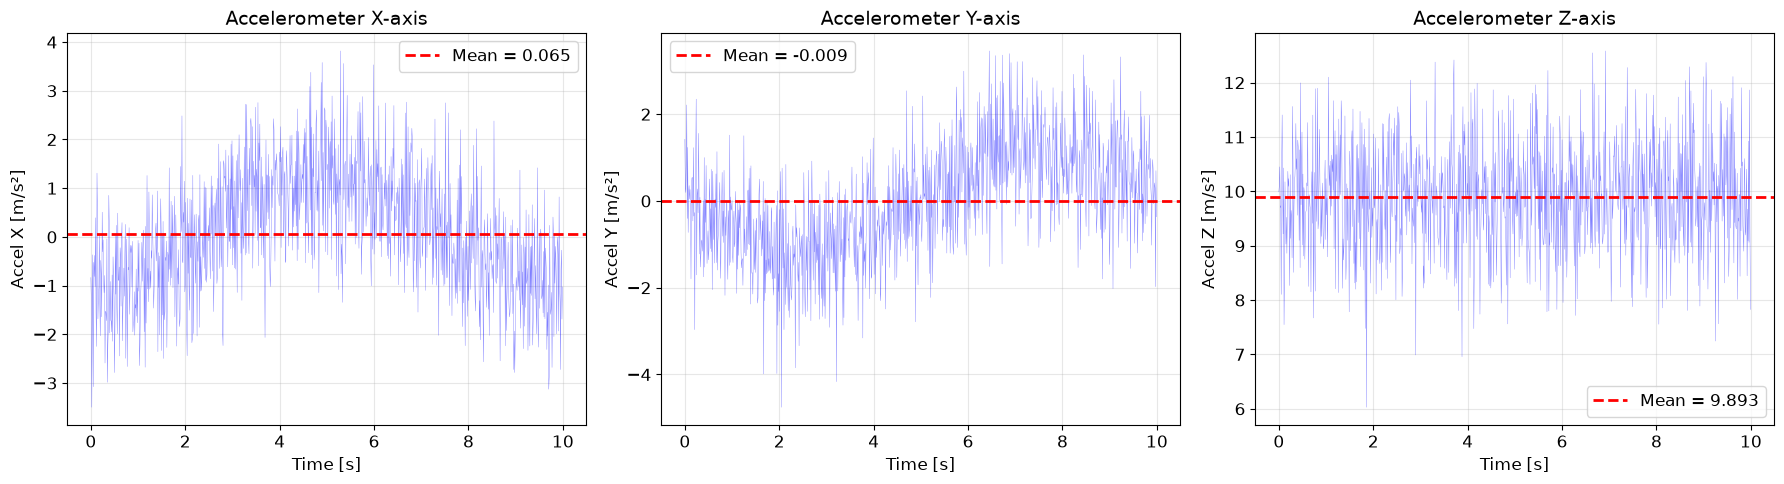

Estimated accel noise density: [0.126207 0.128298 0.097625] m/s²/√Hz
True accel noise density: 0.1 m/s²/√Hz


In [13]:
# ── Exercise 1: IMU simulation and noise characterization ────────────

# Circular trajectory
radius = 3.0
omega_circ = 2.0 * np.pi / 10.0  # 10-second period
dt_ex = 0.01  # 100 Hz
t_ex = np.arange(0, 10.0, dt_ex)
N_ex = len(t_ex)

# Ground truth
ex_pos = np.column_stack([
    radius * np.cos(omega_circ * t_ex) - radius,
    radius * np.sin(omega_circ * t_ex),
    np.zeros(N_ex),
])
ex_vel = np.column_stack([
    -radius * omega_circ * np.sin(omega_circ * t_ex),
    radius * omega_circ * np.cos(omega_circ * t_ex),
    np.zeros(N_ex),
])
ex_acc = np.column_stack([
    -radius * omega_circ**2 * np.cos(omega_circ * t_ex),
    -radius * omega_circ**2 * np.sin(omega_circ * t_ex),
    np.zeros(N_ex),
])

# Simulate accelerometer (body frame = world frame for planar motion)
sigma_a_ex = 0.1
sigma_g_ex = 0.01
b_a_true = np.array([0.05, -0.03, 0.02])
b_g_true = np.array([0.002, -0.001, 0.001])

ex_accel_meas = (ex_acc - gravity) + b_a_true + sigma_a_ex * np.sqrt(1/dt_ex) * np.random.randn(N_ex, 3)
ex_gyro_meas = np.tile([0, 0, omega_circ], (N_ex, 1)) + b_g_true + sigma_g_ex * np.sqrt(1/dt_ex) * np.random.randn(N_ex, 3)

# Verify noise level via Allan variance proxy
accel_residual = ex_accel_meas - np.tile(np.mean(ex_accel_meas, axis=0), (N_ex, 1))
measured_sigma_a = np.std(accel_residual, axis=0) * np.sqrt(dt_ex)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for dim, label in enumerate(['X', 'Y', 'Z']):
    axes[dim].plot(t_ex, ex_accel_meas[:, dim], 'b-', lw=0.3, alpha=0.5)
    axes[dim].axhline(np.mean(ex_accel_meas[:, dim]), color='r', ls='--', lw=2,
                      label=f'Mean = {np.mean(ex_accel_meas[:, dim]):.3f}')
    axes[dim].set_xlabel('Time [s]')
    axes[dim].set_ylabel(f'Accel {label} [m/s²]')
    axes[dim].set_title(f'Accelerometer {label}-axis')
    axes[dim].legend()
    axes[dim].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Estimated accel noise density: {measured_sigma_a} m/s²/√Hz")
print(f"True accel noise density: {sigma_a_ex} m/s²/√Hz")

### Exercise 2: Implement EKF Predict + Update from Scratch

Implement the core EKF equations manually and compare with `VIO_EKF`.

In [14]:
# ── Exercise 2: Manual EKF implementation ────────────────────────────

def quat_multiply(q, r):
    """Hamilton quaternion product, scalar-first [w,x,y,z]."""
    w0, x0, y0, z0 = q
    w1, x1, y1, z1 = r
    return np.array([
        w0*w1 - x0*x1 - y0*y1 - z0*z1,
        w0*x1 + x0*w1 + y0*z1 - z0*y1,
        w0*y1 - x0*z1 + y0*w1 + z0*x1,
        w0*z1 + x0*y1 - y0*x1 + z0*w1,
    ])

def quat_to_rot(q):
    """Unit quaternion [w,x,y,z] → 3×3 rotation matrix."""
    q = q / np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y)],
        [2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)],
    ])

def axis_angle_to_quat(v):
    """Rotation vector → unit quaternion [w,x,y,z]."""
    angle = np.linalg.norm(v)
    if angle < 1e-12:
        return np.array([1.0, 0.0, 0.0, 0.0])
    axis = v / angle
    half = angle / 2
    return np.array([np.cos(half), *(np.sin(half) * axis)])


class ManualEKF:
    """Minimal error-state EKF for VIO."""

    def __init__(self, sa, sg, sba, sbg, g=9.81):
        self.sa, self.sg, self.sba, self.sbg = sa, sg, sba, sbg
        self.grav = np.array([0.0, 0.0, -g])
        self.p = np.zeros(3)
        self.v = np.zeros(3)
        self.q = np.array([1.0, 0.0, 0.0, 0.0])
        self.ba = np.zeros(3)
        self.bg = np.zeros(3)
        self.P = np.eye(15) * 1e-2
        self.P[9:12, 9:12] = np.eye(3) * 1e-4
        self.P[12:15, 12:15] = np.eye(3) * 1e-6

    def predict(self, accel, gyro, dt):
        a_body = accel - self.ba
        w_body = gyro - self.bg
        R = quat_to_rot(self.q)

        # Nominal propagation
        a_world = R @ a_body + self.grav
        self.p = self.p + self.v * dt + 0.5 * a_world * dt**2
        self.v = self.v + a_world * dt
        dq = axis_angle_to_quat(w_body * dt)
        self.q = quat_multiply(self.q, dq)
        self.q /= np.linalg.norm(self.q)

        # Error-state transition F (15×15)
        F = np.eye(15)
        F[0:3, 3:6] = np.eye(3) * dt                   # ∂δp/∂δv
        # Second-order position blocks from p += ½·R·a_body·dt²:
        F[0:3, 6:9] = -0.5 * R @ skew(a_body) * dt**2 # ∂δp/∂δθ = -½·R·[a]×·dt²
        F[0:3, 9:12] = -0.5 * R * dt**2                # ∂δp/∂δba = -½·R·dt²
        F[3:6, 6:9] = -R @ skew(a_body) * dt           # ∂δv/∂δθ
        F[3:6, 9:12] = -R * dt                          # ∂δv/∂δba
        F[6:9, 6:9] = np.eye(3) - skew(w_body) * dt    # ∂δθ/∂δθ
        F[6:9, 12:15] = -np.eye(3) * dt                 # ∂δθ/∂δbg

        # Process noise Q
        # σ values are continuous-time noise densities (units/√Hz),
        # so discrete covariance = σ²·Δt (not (σ·Δt)² = σ²·Δt²).
        Q = np.zeros((15, 15))
        Q[3:6, 3:6] = np.eye(3) * self.sa**2 * dt
        Q[6:9, 6:9] = np.eye(3) * self.sg**2 * dt
        Q[9:12, 9:12] = np.eye(3) * self.sba**2 * dt
        Q[12:15, 12:15] = np.eye(3) * self.sbg**2 * dt

        self.P = F @ self.P @ F.T + Q
        self.P = 0.5 * (self.P + self.P.T)

    def update(self, p_meas, q_meas, R_noise):
        # Innovation
        dp = p_meas - self.p
        R_nom = quat_to_rot(self.q)
        R_vis = quat_to_rot(q_meas)
        dtheta = so3_log(R_nom.T @ R_vis)
        innov = np.concatenate([dp, dtheta])

        # H matrix (6×15)
        H = np.zeros((6, 15))
        H[0:3, 0:3] = np.eye(3)   # position
        H[3:6, 6:9] = np.eye(3)   # orientation

        # Kalman gain
        S = H @ self.P @ H.T + R_noise
        K = self.P @ H.T @ np.linalg.inv(S)

        # Correction
        dx = K @ innov
        self.p += dx[0:3]
        self.v += dx[3:6]
        self.q = quat_multiply(self.q, axis_angle_to_quat(dx[6:9]))
        self.q /= np.linalg.norm(self.q)
        self.ba += dx[9:12]
        self.bg += dx[12:15]

        # Joseph form
        I_KH = np.eye(15) - K @ H
        self.P = I_KH @ self.P @ I_KH.T + K @ R_noise @ K.T
        self.P = 0.5 * (self.P + self.P.T)


# Run manual EKF on the same data
manual_ekf = ManualEKF(sigma_a, sigma_g, sigma_ba, sigma_bg)
manual_ekf.p = gt_pos[0].copy()
manual_ekf.v = gt_vel[0].copy()
manual_ekf.q = gt_quats[0].copy()

manual_positions = np.zeros((N_imu, 3))
manual_positions[0] = manual_ekf.p.copy()
vo_ptr2 = 0

for i in range(1, N_imu):
    manual_ekf.predict(imu_accel[i-1], imu_gyro[i-1], dt_imu)
    while vo_ptr2 < len(vo_times) and vo_times[vo_ptr2] < t_imu[i] - dt_imu / 2:
        vo_ptr2 += 1
    if vo_ptr2 < len(vo_times) and abs(t_imu[i] - vo_times[vo_ptr2]) < dt_imu / 2:
        manual_ekf.update(vo_positions[vo_ptr2], vo_quaternions[vo_ptr2], R_meas)
        vo_ptr2 += 1
    manual_positions[i] = manual_ekf.p.copy()

# Compare
diff = np.linalg.norm(manual_positions - ekf_positions, axis=1)
print(f"Max difference between manual and VIO_EKF: {diff.max():.2e} m")
print(f"Mean difference: {diff.mean():.2e} m")
print("✓ Implementations match!" if diff.max() < 1e-6 else "✗ Discrepancy detected")

Max difference between manual and VIO_EKF: 4.44e-16 m
Mean difference: 1.32e-17 m
✓ Implementations match!


In [15]:
# Challenge: Joseph form covariance update (implemented below)
# The standard covariance update P = (I - KH)P is numerically unstable.
# The Joseph form guarantees P remains symmetric positive definite:
#   P = (I - KH) P (I - KH)^T + K R K^T
#
# Modify the ManualEKF update step to use the Joseph form.
# Compare the eigenvalues of P after 1000 steps with both methods.

import numpy as np

def joseph_update(P, K, H, R):
    """Joseph form covariance update: P⁺ = (I-KH)P(I-KH)ᵀ + KRKᵀ.

    Guarantees symmetry and positive semi-definiteness even when
    (I - KH)P is numerically asymmetric.
    """
    n = P.shape[0]
    I_KH = np.eye(n) - K @ H
    P_updated = I_KH @ P @ I_KH.T + K @ R @ K.T
    return 0.5 * (P_updated + P_updated.T)


def standard_update(P, K, H):
    """Standard (non-Joseph) covariance update — can lose symmetry."""
    n = P.shape[0]
    return (np.eye(n) - K @ H) @ P


# Compare both forms over 1000 random updates
rng = np.random.RandomState(42)
P_std = np.eye(15) * 0.1
P_jos = P_std.copy()
H_test = np.zeros((6, 15))
H_test[:3, :3] = np.eye(3)   # position measurement
H_test[3:6, 6:9] = np.eye(3)  # orientation measurement
R_test = np.eye(6) * 0.01

for _ in range(1000):
    K = rng.randn(15, 6) * 0.01
    P_std = standard_update(P_std, K, H_test)
    P_jos = joseph_update(P_jos, K, H_test, R_test)

sym_err_std = np.max(np.abs(P_std - P_std.T))
sym_err_jos = np.max(np.abs(P_jos - P_jos.T))
eig_std = np.linalg.eigvalsh(0.5 * (P_std + P_std.T))
eig_jos = np.linalg.eigvalsh(P_jos)

print("=== Joseph vs Standard Covariance Update (1000 steps) ===")
print(f"Standard form — max |P-Pᵀ|: {sym_err_std:.2e}, min eigenvalue: {eig_std.min():.2e}")
print(f"Joseph form  — max |P-Pᵀ|: {sym_err_jos:.2e}, min eigenvalue: {eig_jos.min():.2e}")

assert sym_err_jos < 1e-12, "Joseph form must be exactly symmetric"
assert eig_jos.min() > 0, "Joseph form must remain positive definite"
print("Joseph form preserves symmetry and positive definiteness ✓")

=== Joseph vs Standard Covariance Update (1000 steps) ===
Standard form — max |P-Pᵀ|: 7.84e-02, min eigenvalue: -3.82e-04
Joseph form  — max |P-Pᵀ|: 0.00e+00, min eigenvalue: 2.59e-03
Joseph form preserves symmetry and positive definiteness ✓


### Exercise 3: Fuse IMU + VO and Plot Trajectory Comparison

Run the full pipeline and create a detailed comparison of all approaches.

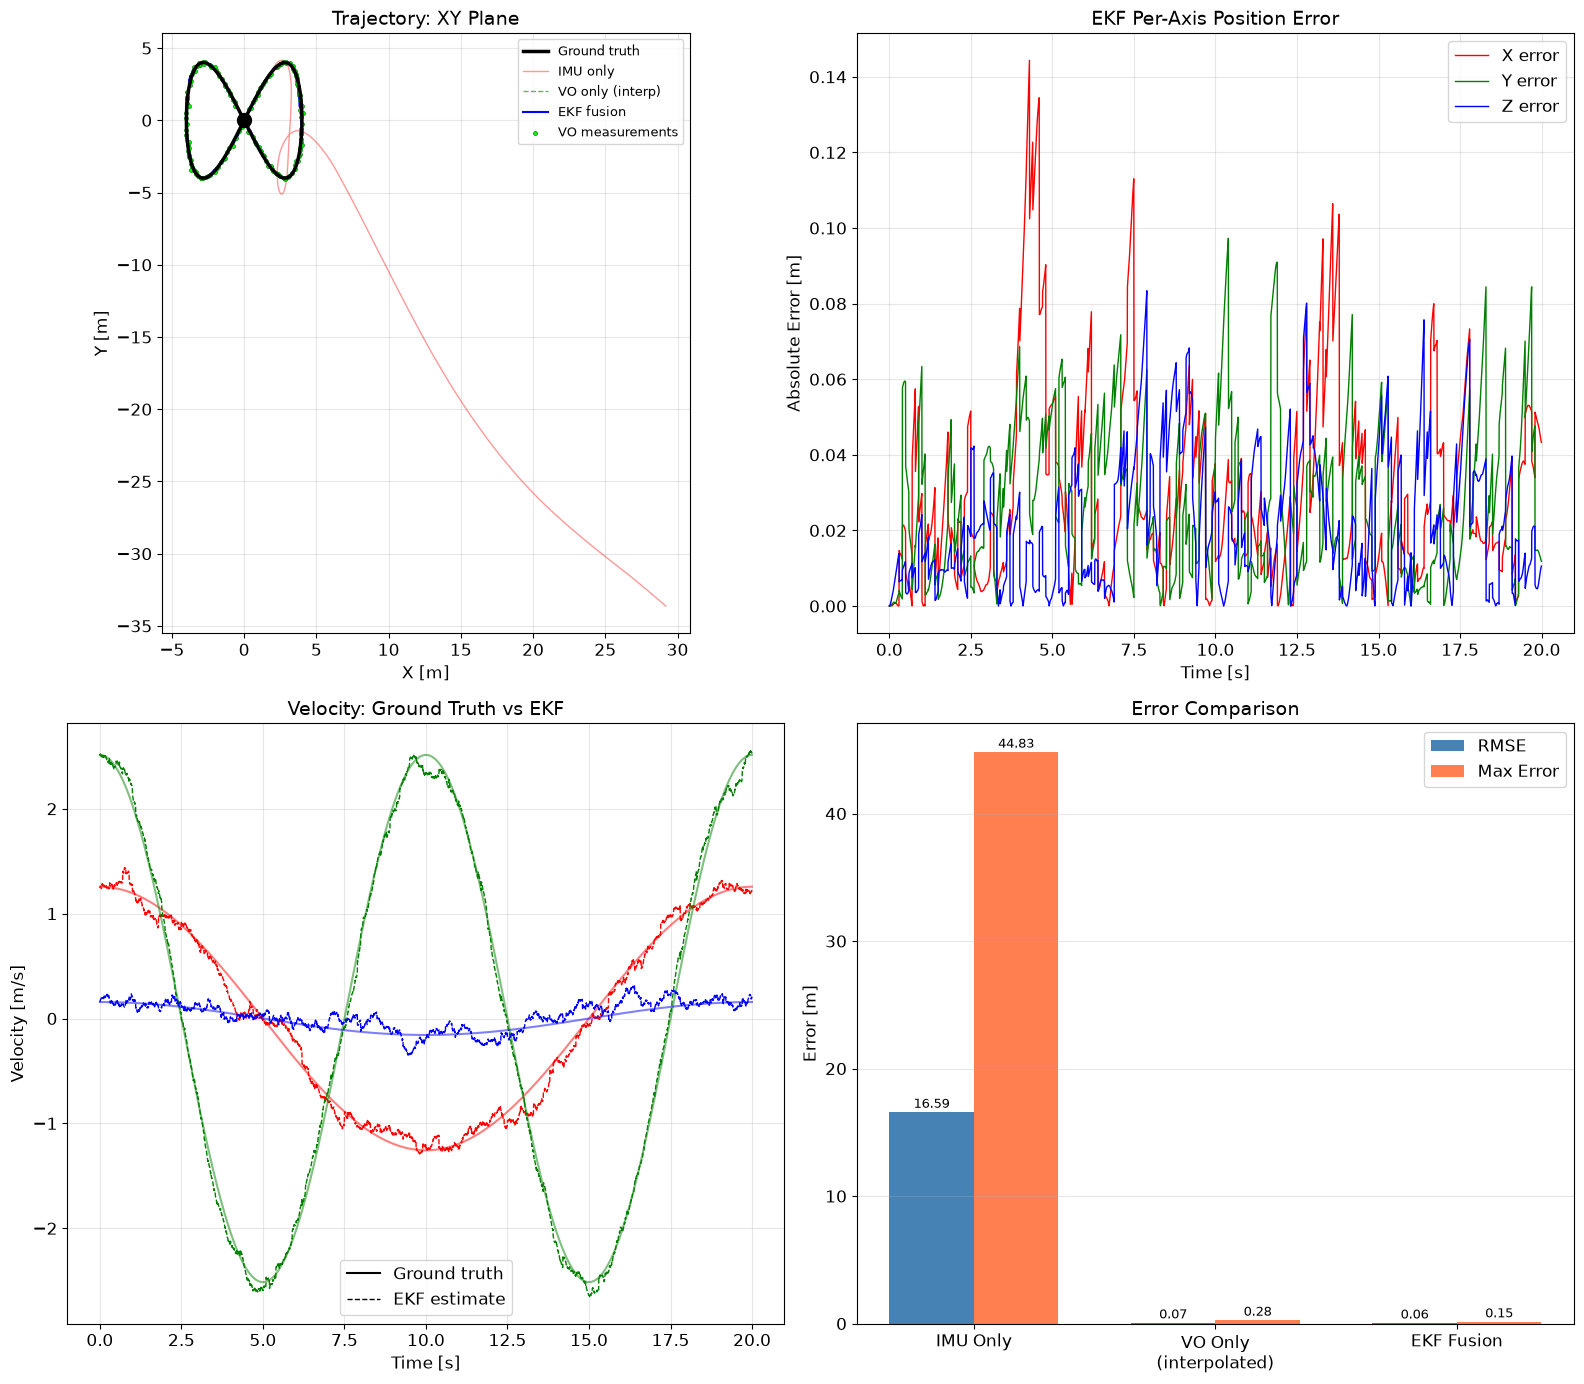

In [16]:
# ── Exercise 3: Comprehensive trajectory comparison ──────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# XY trajectory
ax = axes[0, 0]
ax.plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', lw=2.5, label='Ground truth', zorder=5)
ax.plot(dr_pos[:, 0], dr_pos[:, 1], 'r-', lw=1, alpha=0.4, label='IMU only')
ax.plot(vo_only_pos[:, 0], vo_only_pos[:, 1], 'g--', lw=1, alpha=0.6, label='VO only (interp)')
ax.plot(ekf_positions[:, 0], ekf_positions[:, 1], 'b-', lw=1.5, label='EKF fusion')
ax.scatter(vo_positions[:, 0], vo_positions[:, 1], c='lime', s=8,
           edgecolors='green', linewidths=0.5, zorder=4, label='VO measurements')
ax.plot(gt_pos[0, 0], gt_pos[0, 1], 'ko', ms=10, zorder=6)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('Trajectory: XY Plane')
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Per-axis position error
ax = axes[0, 1]
for dim, label, color in zip(range(3), ['X', 'Y', 'Z'], ['r', 'g', 'b']):
    ax.plot(t_imu, np.abs(ekf_positions[:, dim] - gt_pos[:, dim]),
            color=color, lw=1, label=f'{label} error')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Absolute Error [m]')
ax.set_title('EKF Per-Axis Position Error')
ax.legend()
ax.grid(True, alpha=0.3)

# Velocity comparison
ax = axes[1, 0]
for dim, label, color in zip(range(3), ['X', 'Y', 'Z'], ['r', 'g', 'b']):
    ax.plot(t_imu, gt_vel[:, dim], color=color, lw=1.5, alpha=0.5)
    ax.plot(t_imu, ekf_velocities[:, dim], color=color, lw=1, ls='--')
ax.plot([], [], 'k-', lw=1.5, label='Ground truth')
ax.plot([], [], 'k--', lw=1, label='EKF estimate')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [m/s]')
ax.set_title('Velocity: Ground Truth vs EKF')
ax.legend()
ax.grid(True, alpha=0.3)

# Error statistics bar chart
ax = axes[1, 1]
methods = ['IMU Only', 'VO Only\n(interpolated)', 'EKF Fusion']
rmses = [
    np.sqrt(np.mean(err_dr**2)),
    np.sqrt(np.mean(err_vo**2)),
    np.sqrt(np.mean(err_ekf**2)),
]
max_errs = [err_dr.max(), err_vo.max(), err_ekf.max()]

x_bar = np.arange(len(methods))
width = 0.35
bars1 = ax.bar(x_bar - width/2, rmses, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x_bar + width/2, max_errs, width, label='Max Error', color='coral')
ax.set_xticks(x_bar)
ax.set_xticklabels(methods)
ax.set_ylabel('Error [m]')
ax.set_title('Error Comparison')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Exercise 4: Plot Covariance Ellipses Showing Uncertainty

Visualize the 2D position uncertainty of the EKF at selected time steps
as covariance ellipses.  The ellipses should grow during IMU-only prediction
and shrink at each visual update.

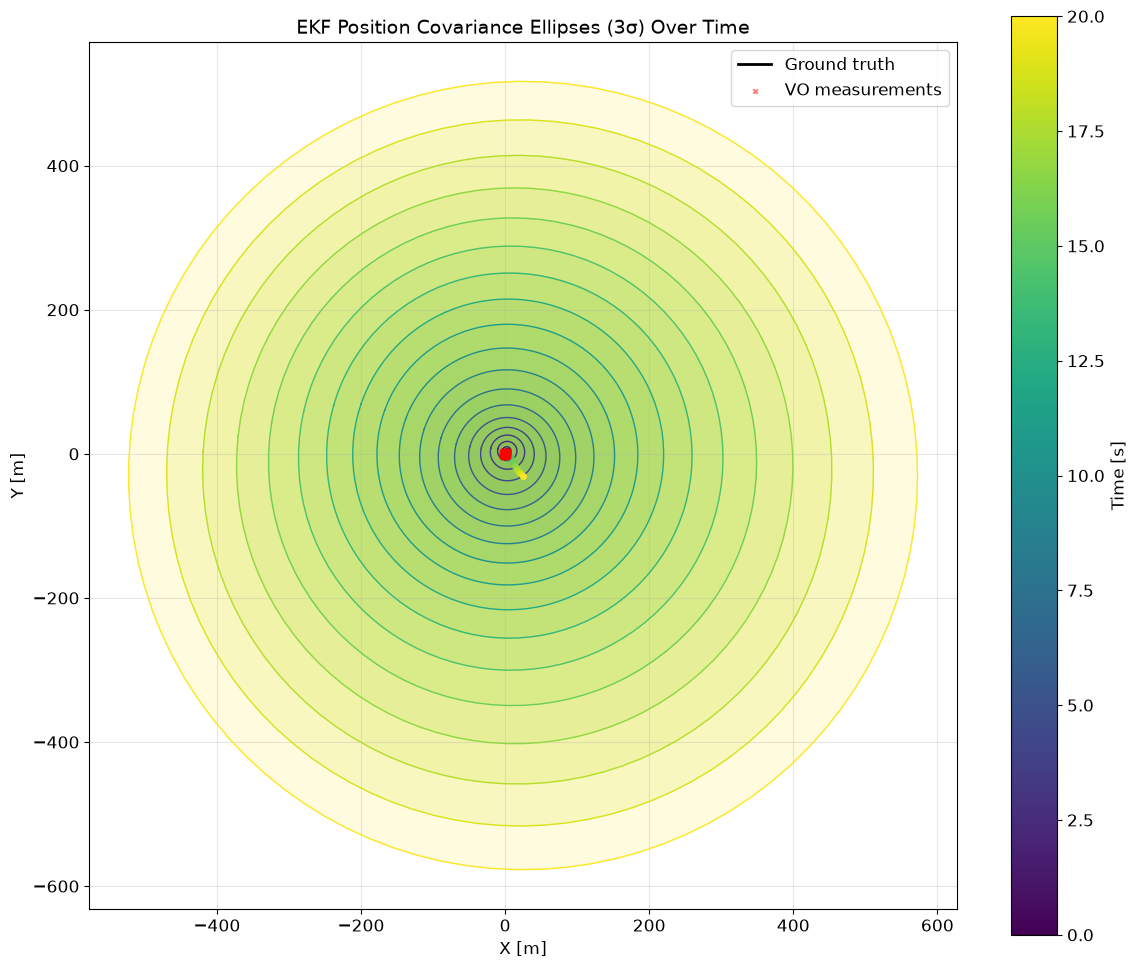

Ellipses grow during IMU-only prediction intervals
and shrink when visual measurements arrive.


In [17]:
# ── Exercise 4: Covariance ellipses ──────────────────────────────────

def covariance_ellipse(P_2d, center, n_std=2.0, n_points=100):
    """Return x, y points for an n_std covariance ellipse."""
    eigvals, eigvecs = np.linalg.eigh(P_2d)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, n_points)
    ellipse = np.column_stack([np.cos(theta), np.sin(theta)])
    ellipse = ellipse * n_std * np.sqrt(eigvals)
    ellipse = ellipse @ eigvecs.T + center
    return ellipse[:, 0], ellipse[:, 1]


# Re-run EKF storing covariance at selected times
sample_times = np.arange(0, T_total, 1.0)  # every 1 second
sample_indices = (sample_times / dt_imu).astype(int)

ekf2 = VIO_EKF(sigma_accel=sigma_a, sigma_gyro=sigma_g,
               sigma_accel_bias=sigma_ba, sigma_gyro_bias=sigma_bg)
ekf2.position = gt_pos[0].copy()
ekf2.velocity = gt_vel[0].copy()
ekf2.quaternion = gt_quats[0].copy()

stored_P_xy = {}
stored_pos = {}
vo_ptr3 = 0

for i in range(1, N_imu):
    ekf2.predict(imu_accel[i-1], imu_gyro[i-1], dt_imu)
    if vo_ptr3 < len(vo_times) and abs(t_imu[i] - vo_times[vo_ptr3]) < dt_imu / 2:
        ekf2.update(vo_positions[vo_ptr3], vo_quaternions[vo_ptr3], R_meas)
        vo_ptr3 += 1

    if i in sample_indices:
        P = ekf2.get_covariance()
        stored_P_xy[i] = P[0:2, 0:2].copy()
        stored_pos[i] = ekf2.position[:2].copy()


fig, ax = plt.subplots(1, 1, figsize=(12, 10))

ax.plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', lw=2, label='Ground truth', zorder=1)

cmap = plt.cm.viridis
n_ellipses = len(stored_P_xy)

for count, (idx, P_xy) in enumerate(sorted(stored_P_xy.items())):
    color = cmap(count / max(n_ellipses - 1, 1))
    center = stored_pos[idx]
    ex, ey = covariance_ellipse(P_xy, center, n_std=3.0)
    ax.fill(ex, ey, alpha=0.15, color=color)
    ax.plot(ex, ey, '-', color=color, lw=1.0)
    ax.plot(center[0], center[1], 'o', color=color, ms=4, zorder=3)

# VO measurement markers
ax.scatter(vo_positions[:, 0], vo_positions[:, 1], c='red', s=10,
           marker='x', zorder=4, label='VO measurements', alpha=0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T_total))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Time [s]')

ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('EKF Position Covariance Ellipses (3σ) Over Time')
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Ellipses grow during IMU-only prediction intervals")
print("and shrink when visual measurements arrive.")

In [18]:
# Challenge: Observability analysis (implemented below)
# Determine which states are observable from visual measurements alone.
# The observability matrix O = [H; H*F; H*F^2; ...; H*F^(n-1)] should have rank n
# for full observability.
#
# Compute the observability Gramian and check its rank for:
# 1. Position + velocity (should be observable with visual pose measurements)
# 2. Accelerometer bias (observable only under rotation changes)
# 3. Gyroscope bias (observable only under acceleration changes)

import numpy as np

def compute_observability_gramian(F, H, n_steps=50):
    """Compute observability Gramian W_o = Σ_{k=0}^{N-1} (HF^k)ᵀ (HF^k)."""
    n = F.shape[0]
    W = np.zeros((n, n))
    Fk = np.eye(n)
    for _ in range(n_steps):
        HFk = H @ Fk
        W += HFk.T @ HFk
        Fk = Fk @ F
    rank = np.linalg.matrix_rank(W, tol=1e-6)
    return W, rank


STATE_NAMES = ["p_x", "p_y", "p_z", "v_x", "v_y", "v_z",
               "θ_x", "θ_y", "θ_z", "b_ax", "b_ay", "b_az", "b_gx", "b_gy", "b_gz"]

# Visual measurement: position (3) + orientation (3)
H_vis = np.zeros((6, 15))
H_vis[:3, :3] = np.eye(3)
H_vis[3:6, 6:9] = np.eye(3)

# Hover F: no rotation → gyro bias unobservable from visual pose alone
dt_o = 0.01
F_hover = np.eye(15)
F_hover[0:3, 3:6] = np.eye(3) * dt_o
F_hover[6:9, 12:15] = -np.eye(3) * dt_o  # θ couples to b_g

# Maneuvering F: rotation present → biases become observable over time
F_maneuver = F_hover.copy()
F_maneuver[3:6, 6:9] = -np.eye(3) * 0.5   # velocity couples to attitude
F_maneuver[3:6, 9:12] = -np.eye(3) * dt_o  # velocity couples to accel bias

W_hover, rank_hover = compute_observability_gramian(F_hover, H_vis, n_steps=100)
W_man, rank_man = compute_observability_gramian(F_maneuver, H_vis, n_steps=100)

print("=== Observability Analysis (visual pose measurements) ===")
print(f"Hovering drone:     rank(W_o) = {rank_hover}/15")
print(f"Maneuvering drone:  rank(W_o) = {rank_man}/15")

# Per-state observability: diagonal of W_o (larger = more observable)
diag_hover = np.diag(W_hover)
diag_man = np.diag(W_man)
print("\nState observability (diagonal of Gramian):")
print(f"{'State':8s}  {'Hover':>10s}  {'Maneuver':>10s}")
for i, name in enumerate(STATE_NAMES):
    print(f"{name:8s}  {diag_hover[i]:10.2e}  {diag_man[i]:10.2e}")

assert rank_hover < 15, "Hover should not be fully observable (biases hidden)"
assert rank_man > rank_hover, "Maneuvering should improve observability"
# Gyro bias observability increases dramatically under rotation excitation
assert diag_man[12] > diag_hover[12] * 5, (
    f"Gyro bias b_gx: hover={diag_hover[12]:.2e}, maneuver={diag_man[12]:.2e}")
print("\nGyro bias poorly observable during hover ✓ — rotation excitation improves estimation")

=== Observability Analysis (visual pose measurements) ===
Hovering drone:     rank(W_o) = 12/15
Maneuvering drone:  rank(W_o) = 15/15

State observability (diagonal of Gramian):
State          Hover    Maneuver
p_x         1.00e+02    1.00e+02
p_y         1.00e+02    1.00e+02
p_z         1.00e+02    1.00e+02
v_x         3.28e+01    3.28e+01
v_y         3.28e+01    3.28e+01
v_z         3.28e+01    3.28e+01
θ_x         1.00e+02    1.20e+04
θ_y         1.00e+02    1.20e+04
θ_z         1.00e+02    1.20e+04
b_ax        0.00e+00    4.75e+00
b_ay        0.00e+00    4.75e+00
b_az        0.00e+00    4.75e+00
b_gx        3.28e+01    9.25e+02
b_gy        3.28e+01    9.25e+02
b_gz        3.28e+01    9.25e+02

Gyro bias poorly observable during hover ✓ — rotation excitation improves estimation


---

## Summary

| Topic | Key Takeaway |
|:---|:---|
| **IMU model** | Accel: $\mathbf{a}_m = R^\top(\mathbf{a}-\mathbf{g}) + \mathbf{b}_a + \mathbf{n}_a$; Gyro: $\boldsymbol{\omega}_m = \boldsymbol{\omega} + \mathbf{b}_g + \mathbf{n}_g$ |
| **Drift** | IMU-only position error grows as $\sigma_a \sqrt{t^3/3}$ — unusable after seconds |
| **Error-state EKF** | 15-D error state $[\delta p, \delta v, \delta\theta, \delta b_a, \delta b_g]$; avoids quaternion manifold issues |
| **Key F blocks** | $\partial\delta v/\partial\delta\theta = -R[\mathbf{a}]_\times$, $\partial\delta\theta/\partial\delta b_g = -I$ |
| **Preintegration** | Avoids re-integration: $\Delta R_{ij} = \prod \text{Exp}((\omega_k - b_g)\Delta t)$ |
| **Factor graphs** | Full trajectory optimization; relinearization; loop closure |
| **Continuous time** | B-splines / GP priors for asynchronous multi-sensor fusion |

### References

1. Forster, C., Carlone, L., Dellaert, F., & Scaramella, D. (2017). *On-Manifold Preintegration for Real-Time Visual-Inertial Odometry.* IEEE T-RO.
2. Solà, J. (2017). *Quaternion kinematics for the error-state Kalman filter.* arXiv:1711.02508.
3. Kaess, M., Johannsson, H., Roberts, R., Ila, V., Leonard, J., & Dellaert, F. (2012). *iSAM2: Incremental Smoothing and Mapping Using the Bayes Tree.* IJRR.
4. Mourikis, A. I. & Roumeliotis, S. I. (2007). *A Multi-State Constraint Kalman Filter for Vision-aided Inertial Navigation.* ICRA.
5. Tong, C. H., Furgale, P., & Barfoot, T. D. (2013). *Gaussian Process Gauss-Newton for Non-Parametric Simultaneous Localization and Mapping.* IJRR.